# PyPSA Electricity Network Model - TYNDP 2030

This notebook builds an electricity-only network model for Europe based on TYNDP 2024 data for the year 2030.

## Phase 1: Setup & Data Loading

Import necessary libraries and load all data files from `data/open-tyndp/`.

In [2]:
!python3.12 -m pip install --upgrade pip
!python3.12 -m pip install pypsa matplotlib seaborn pandas numpy

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import pypsa
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import helper functions
sys.path.append('grid-model')
import importlib
import helpers
importlib.reload(helpers)
from helpers import (
    GENERATOR_CARRIERS, STORAGE_CARRIERS,
    WIND_CARRIERS, SOLAR_CARRIERS,
    HYDRO_ROR_CARRIERS, HYDRO_DISPATCHABLE_CARRIERS,
    CONVENTIONAL_CARRIERS,
    VRE_CARRIERS, RES_CARRIERS
)

print(f"PyPSA version: {pypsa.__version__}")
print(f"Generator carriers: {len(GENERATOR_CARRIERS)}")
print(f"Storage carriers: {len(STORAGE_CARRIERS)}")
print(f"Wind carriers: {len(WIND_CARRIERS)}")
print(f"Solar carriers: {len(SOLAR_CARRIERS)}")
print(f"Hydro RoR carriers: {len(HYDRO_ROR_CARRIERS)}")
print(f"Conventional carriers: {len(CONVENTIONAL_CARRIERS)}")
print(f"Conventional carriers: {len(CONVENTIONAL_CARRIERS)}")

PyPSA version: 1.0.7
Generator carriers: 23
Storage carriers: 3
Wind carriers: 2
Solar carriers: 4
Hydro RoR carriers: 1
Conventional carriers: 13
Conventional carriers: 13


In [4]:
# Define data directory
DATA_DIR = Path("data/open-tyndp")

# Load all CSV files

# Network topology
buses = pd.read_csv(DATA_DIR / "buses.csv")
links = pd.read_csv(DATA_DIR / "links.csv")

# Capacities and costs (using GROUPED capacities - already aggregated by bus+carrier)
capacities = pd.read_csv(DATA_DIR / "pemmdb_capacities_2030_grouped.csv")
costs = pd.read_csv(DATA_DIR / "costs_2030_processed.csv")
technologies = pd.read_csv(DATA_DIR / "technologies_2030.csv")

# Demand
electricity_demand = pd.read_csv(DATA_DIR / "electricity_demand_2030.csv", index_col=0, parse_dates=True)

# Availability profiles for renewables
wind_onshore = pd.read_csv(DATA_DIR / "pecd_data_Wind_Onshore_2030.csv", index_col=0, parse_dates=True)
wind_offshore = pd.read_csv(DATA_DIR / "pecd_data_Wind_Offshore_2030.csv", index_col=0, parse_dates=True)
solar_utility = pd.read_csv(DATA_DIR / "pecd_data_LFSolarPVUtility_2030.csv", index_col=0, parse_dates=True)
solar_rooftop = pd.read_csv(DATA_DIR / "pecd_data_LFSolarPVRooftop_2030.csv", index_col=0, parse_dates=True)

# Availability profile for thermal/synchronous generators
thermal_avail = pd.read_csv(DATA_DIR / "avail_profile_s_all.csv", index_col=0, parse_dates=True)

# Hydro inflows (5 types)
hydro_ror = pd.read_csv(DATA_DIR / "hydro_inflows_tyndp_Run_of_River_2030.csv", index_col=0, parse_dates=True)
hydro_reservoir = pd.read_csv(DATA_DIR / "hydro_inflows_tyndp_Reservoir_2030.csv", index_col=0, parse_dates=True)
hydro_pondage = pd.read_csv(DATA_DIR / "hydro_inflows_tyndp_Pondage_2030.csv", index_col=0, parse_dates=True)
hydro_ps_open = pd.read_csv(DATA_DIR / "hydro_inflows_tyndp_PS_Open_2030.csv", index_col=0, parse_dates=True)
hydro_ps_closed = pd.read_csv(DATA_DIR / "hydro_inflows_tyndp_PS_Closed_2030.csv", index_col=0, parse_dates=True)

# CO2 totals (for validation)
co2_totals = pd.read_csv(DATA_DIR / "co2_totals.csv")

print("  All data files loaded successfully!\n")

# Display basic info
print(f"  Data Summary:")
print(f"   Buses: {len(buses)} nodes")
print(f"   Links: {len(links)} connections")
print(f"   Capacities: {len(capacities)} rows × {len(capacities.columns)} technologies")
print(f"   Demand timesteps: {len(electricity_demand)}")
print(f"   Wind onshore timesteps: {len(wind_onshore)}")
print(f"   Wind offshore timesteps: {len(wind_offshore)}")
print(f"   Solar utility timesteps: {len(solar_utility)}")
print(f"   Solar rooftop timesteps: {len(solar_rooftop)}")
print(f"   Thermal availability timesteps: {len(thermal_avail)}")

  All data files loaded successfully!

  Data Summary:
   Buses: 55 nodes
   Links: 219 connections
   Capacities: 2010 rows × 9 technologies
   Demand timesteps: 8760
   Wind onshore timesteps: 8760
   Wind offshore timesteps: 8760
   Solar utility timesteps: 8760
   Solar rooftop timesteps: 8760
   Thermal availability timesteps: 8760


## Phase 2: Network Topology

Create PyPSA network and add buses (nodes) and transmission lines.

In [5]:
# Create PyPSA network
network = pypsa.Network()
network.name = "TYNDP2024_Electricity_2030"

# Set snapshots - we'll start with a single snapshot, then expand in Phase 6
network.set_snapshots(pd.date_range('2030-01-01', periods=1, freq='h'))

print(f"  Created network: {network.name}")
print(f"   Initial snapshots: {len(network.snapshots)}")

  Created network: TYNDP2024_Electricity_2030
   Initial snapshots: 1


In [6]:
# Inspect buses data structure
print("  Buses data structure:")
print(buses.head())
print(f"\nColumns: {buses.columns.tolist()}")
print(f"\nSample bus codes: {buses['bus_id'].head(10).tolist()}")

  Buses data structure:
  bus_id station_id  voltage  dc      symbol under_construction  tags  \
0   AL00       AL00      380 NaN  Substation                  f  AL00   
1   AT00       AT00      380 NaN  Substation                  f  AT00   
2   BA00       BA00      380 NaN  Substation                  f  BA00   
3   BE00       BE00      380 NaN  Substation                  f  BE00   
4   BG00       BG00      380 NaN  Substation                  f  BG00   

           x          y country                                       geometry  
0  20.036884  41.117588      AL  POINT (20.036883988642362 41.117587702511265)  
1  14.822183  47.668898      AT   POINT (14.822183225330722 47.66889815500067)  
2  17.867837  43.982016      BA   POINT (17.867837381251395 43.98201574415204)  
3   4.967931  50.470635      BE     POINT (4.96793113501169 50.47063494467691)  
4  25.323948  42.668760      BG   POINT (25.323948321769798 42.66875960983357)  

Columns: ['bus_id', 'station_id', 'voltage', 'dc',

In [7]:
# Add buses to network
for idx, row in buses.iterrows():
    network.add("Bus",
                name=row['bus_id'],
                x=row['x'],
                y=row['y'],
                country=row['country'],
                v_nom=row.get('voltage', 380))  # nominal voltage in kV

print(f"Added {len(network.buses)} buses to network")
print(f"\nSample buses:")
print(network.buses.head())

Added 55 buses to network

Sample buses:
      v_nom type          x          y carrier unit location  v_mag_pu_set  \
name                                                                         
AL00  380.0       20.036884  41.117588      AC                         1.0   
AT00  380.0       14.822183  47.668898      AC                         1.0   
BA00  380.0       17.867837  43.982016      AC                         1.0   
BE00  380.0        4.967931  50.470635      AC                         1.0   
BG00  380.0       25.323948  42.668760      AC                         1.0   

      v_mag_pu_min  v_mag_pu_max control generator sub_network country  
name                                                                    
AL00           0.0           inf      PQ                            AL  
AT00           0.0           inf      PQ                            AT  
BA00           0.0           inf      PQ                            BA  
BE00           0.0           inf      PQ       

In [8]:
# Inspect links data structure
print("Links data structure:")
print(links.head(10))
print(f"\nColumns: {links.columns.tolist()}")
print(f"\nLink types: {links['carrier'].unique() if 'carrier' in links.columns else 'No carrier column'}")

Links data structure:
             link_id  bus0  bus1  voltage          p_nom length underground  \
AL00-GR00-DC    AL00  GR00   380      600  219635.110617      t           f   
AL00-ME00-DC    AL00  ME00   380      400  189342.890082      t           f   
AL00-MK00-DC    AL00  MK00   380      500  153308.706607      t           f   
AL00-RS00-DC    AL00  RS00   380      250  351420.535321      t           f   
AT00-CH00-DC    AT00  CH00   380     1200  494893.193612      t           f   
AT00-CZ00-DC    AT00  CZ00   380      900  239946.178070      t           f   
AT00-DE00-DC    AT00  DE00   380     7500  512754.700056      t           f   
AT00-HU00-DC    AT00  HU00   380      800  324765.186895      t           f   
AT00-ITN1-DC    AT00  ITN1   380      875  464387.903281      t           f   
AT00-SI00-DC    AT00  SI00   380      950  167638.650373      t           f   

             under_construction  \
AL00-GR00-DC       AL00 -> GR00   
AL00-ME00-DC       AL00 -> ME00   
AL0

In [9]:
# Add DC links (HVDC) to network
# The index contains the link_id, link_id column contains bus0, bus0 column contains bus1
added_links = 0
skipped_links = 0

for link_id_full, row in links.iterrows():
    bus0 = row['link_id']  # actual bus0
    bus1 = row['bus0']  # actual bus1
    
    # Check if both buses exist in the network
    if bus0 not in network.buses.index or bus1 not in network.buses.index:
        skipped_links += 1
        continue
    
    # Calculate link length from bus coordinates (km)
    x0, y0 = network.buses.loc[bus0, ['x', 'y']]
    x1, y1 = network.buses.loc[bus1, ['x', 'y']]
    # Simple Euclidean distance * 111 km/degree (approximate)
    length_km = np.sqrt((x1-x0)**2 + (y1-y0)**2) * 111
    
    network.add("Link",
                name=link_id_full,
                bus0=bus0,
                bus1=bus1,
                p_nom=row['p_nom'],  # MW capacity
                length=length_km,  # km
                carrier='DC',
                efficiency=0.97,
                p_nom_extendable=False,
                )  # typical HVDC efficiency (3% losses)
    added_links += 1

print(f"Added {added_links} DC links to network")
if skipped_links > 0:
    print(f"⚠️  Skipped {skipped_links} links (buses not found)")
    
print(f"\nSample links:")
print(network.links[['bus0', 'bus1', 'p_nom', 'length', 'carrier', 'efficiency']].head(10))

Added 219 DC links to network

Sample links:
              bus0  bus1          p_nom      length carrier  efficiency
name                                                                   
AL00-GR00-DC  AL00  GR00  219635.110617  245.452182      DC        0.97
AL00-ME00-DC  AL00  ME00  189342.890082  202.828059      DC        0.97
AL00-MK00-DC  AL00  MK00  153308.706607  196.445037      DC        0.97
AL00-RS00-DC  AL00  RS00  351420.535321  356.327878      DC        0.97
AT00-CH00-DC  AT00  CH00  494893.193612  717.623708      DC        0.97
AT00-CZ00-DC  AT00  CZ00  239946.178070  249.446315      DC        0.97
AT00-DE00-DC  AT00  DE00  512754.700056  647.361612      DC        0.97
AT00-HU00-DC  AT00  HU00  324765.186895  475.066001      DC        0.97
AT00-ITN1-DC  AT00  ITN1  464387.903281  619.653116      DC        0.97
AT00-SI00-DC  AT00  SI00  167638.650373  168.474884      DC        0.97


## Phase 3: Add Carriers

Adding diffrenet types of carriers with their co2 emissions.

In [10]:
# ==========================================
# ADD CARRIERS WITH CO2 EMISSIONS
# ==========================================

# Load technologies dataset with pypsa_carrier and CO2 emissions
technologies = pd.read_csv('data/open-tyndp/technologies_2030.csv')

# Get unique carriers with their CO2 emissions
carriers_df = technologies[['pypsa_carrier', 'co2_tco2_mwh']].drop_duplicates()

print(f"Adding {len(carriers_df)} carriers to the network...")
print(f"\nCarriers: {sorted(carriers_df['pypsa_carrier'].unique())}\n")

# Add each carrier to the network
for _, row in carriers_df.iterrows():
    carrier_name = row['pypsa_carrier']
    co2_emissions = row['co2_tco2_mwh']  # tCO2/MWh_electric (already accounts for efficiency)
    
    # Determine nice_name and color based on carrier type
    if carrier_name in ['onwind', 'offwind']:
        color = '#3B6182'  # Blue for wind
        nice_name = 'Wind ' + carrier_name.replace('wind', '').replace('on', 'Onshore').replace('off', 'Offshore')
    elif 'solar' in carrier_name:
        color = '#FFDD00'  # Yellow for solar
        nice_name = carrier_name.replace('-', ' ').title()
    elif 'hydro' in carrier_name:
        color = '#298c81'  # Teal for hydro
        nice_name = carrier_name.replace('-', ' ').title()
    elif carrier_name == 'battery':
        color = '#b8ea04'  # Light green for battery
        nice_name = 'Battery'
    elif carrier_name == 'electrolyser':
        color = '#ff29d9'  # Pink for electrolyser
        nice_name = 'Electrolyser'
    elif carrier_name == 'gas':
        color = '#d35050'  # Red for gas
        nice_name = 'Gas'
    elif carrier_name == 'gas-ccs':
        color = '#ff9494'  # Light red for gas with CCS
        nice_name = 'Gas CCS'
    elif carrier_name == 'coal':
        color = '#707070'  # Dark grey for coal
        nice_name = 'Coal'
    elif carrier_name == 'coal-ccs':
        color = '#b0b0b0'  # Light grey for coal with CCS
        nice_name = 'Coal CCS'
    elif carrier_name == 'lignite':
        color = '#8b4513'  # Brown for lignite
        nice_name = 'Lignite'
    elif carrier_name == 'lignite-ccs':
        color = '#cd853f'  # Light brown for lignite with CCS
        nice_name = 'Lignite CCS'
    elif carrier_name == 'nuclear':
        color = '#ff6600'  # Orange for nuclear
        nice_name = 'Nuclear'
    elif 'oil' in carrier_name:
        color = '#000000'  # Black for oil
        nice_name = carrier_name.replace('-', ' ').title()
    elif carrier_name == 'h2':
        color = '#ea048a'  # Magenta for hydrogen
        nice_name = 'Hydrogen'
    elif carrier_name == 'other-thermal':
        color = '#8B4789'  # Purple for CHP/other thermal
        nice_name = 'Other Thermal'
    else:
        color = '#cccccc'  # Grey for others
        nice_name = carrier_name.replace('-', ' ').title()
    
    network.add("Carrier",
                carrier_name,
                co2_emissions=co2_emissions,  # tCO2/MWh_electric
                color=color,
                nice_name=nice_name
    )

print(f"✓ Added {len(carriers_df)} carriers to the network")
print(f"\nCarriers in network: {len(network.carriers)}")
print(network.carriers[['co2_emissions', 'color', 'nice_name']])

Adding 32 carriers to the network...

Carriers: ['battery', 'coal', 'coal-ccs', 'electrolyser', 'gas', 'gas-ccs', 'h2', 'hydro-phs', 'hydro-phs-pure', 'hydro-pondage', 'hydro-reservoir', 'hydro-ror', 'lignite', 'lignite-ccs', 'nuclear', 'offwind', 'oil-heavy', 'oil-light', 'oil-shale', 'onwind', 'other-res', 'other-thermal', 'solar-pv-rooftop', 'solar-pv-utility', 'solar-thermal', 'solar-thermal-w-storage']

✓ Added 32 carriers to the network

Carriers in network: 26
                         co2_emissions    color                nice_name
name                                                                    
battery                       0.000000  #b8ea04                  Battery
other-thermal                 0.020520  #8B4789            Other Thermal
coal                          0.338400  #707070                     Coal
coal-ccs                      0.033840  #b0b0b0                 Coal CCS
electrolyser                  0.000000  #ff29d9             Electrolyser
gas              

## Phase 4: Add Generators (Updated)

Now we add generators to the network using:
- Capacities from PEMMDB (already loaded)
- Technology parameters from `technologies_2030.csv` (carrier, efficiency, marginal_cost)
- Generators reference carriers that now exist in the network with CO2 emissions

In [11]:
# Prepare generator data by merging capacities with technology parameters
gen_data = capacities[['bus', 'index_carrier', 'p_nom', 'unit']].copy()

# Look up technology parameters from technologies dataset
gen_data = gen_data.merge(
    technologies[['index_carrier', 'pypsa_carrier', 'efficiency', 'marginal_cost_eur_mwh']],
    on='index_carrier',
    how='left'
)

# Filter out storage units using pypsa_carrier (will be handled separately)
gen_data = gen_data[~gen_data['pypsa_carrier'].isin(STORAGE_CARRIERS)]

print(f"Prepared {len(gen_data)} generators for network")
display(gen_data.head(25))

Prepared 1533 generators for network


,bus,index_carrier,p_nom,unit,pypsa_carrier,efficiency,marginal_cost_eur_mwh
0,AL00,coal,0.00,MW,coal,0.356,129.257155
1,AL00,coal-ccs,0.00,MW,coal-ccs,0.356,32.242818
2,AL00,gas-ccgt,300.00,MW,gas,0.580,79.846115
3,AL00,gas-ccgt-ccs,0.00,MW,gas-ccs,0.580,47.559962
4,AL00,gas-conv,0.00,MW,gas,0.580,79.846115
5,AL00,gas-ocgt,0.00,MW,gas,0.410,111.427700
6,AL00,lignite,0.00,MW,lignite,0.330,147.843745
7,AL00,lignite-ccs,0.00,MW,lignite-ccs,0.330,35.392182
8,AL00,nuclear,0.00,MW,nuclear,0.326,22.319406
9,AL00,oil-heavy,0.00,MW,oil-heavy,0.350,196.071357


In [12]:
# Add generators to network
added = 0
skipped = 0

for _, row in gen_data.iterrows():
    bus = row['bus']
    carrier = row['pypsa_carrier']
    p_nom = row['p_nom']
    efficiency = row['efficiency'] if pd.notna(row['efficiency']) and row['efficiency'] > 0 else 1.0
    marginal_cost = row['marginal_cost_eur_mwh'] if pd.notna(row['marginal_cost_eur_mwh']) else 0.0
    
    # Validate data
    if pd.isna(carrier) or p_nom <= 0 or bus not in network.buses.index or carrier not in network.carriers.index:
        skipped += 1
        continue
    
    # Add generator
    gen_name = f"{bus}-{row['index_carrier']}"
    network.add("Generator",
                name=gen_name,
                bus=bus,
                carrier=carrier,
                p_nom=p_nom,
                p_nom_extendable=False,
                # efficiency=efficiency,
                marginal_cost=marginal_cost,
                p_max_pu=1.0
    )
    added += 1

print(f"Added {added} generators to network (skipped {skipped})")
print(f"Total generators: {len(network.generators)}")
print(f"\nCapacity by carrier [GW]:")
print((network.generators.groupby('carrier')['p_nom'].sum() / 1000).sort_values(ascending=False).head(40))

Added 503 generators to network (skipped 1030)
Total generators: 503

Capacity by carrier [GW]:
carrier
solar-pv-utility           416.952834
onwind                     398.954593
solar-pv-rooftop           270.544705
gas                        202.802648
offwind                    149.118470
hydro-reservoir            108.327221
nuclear                    101.795197
electrolyser                93.658371
hydro-ror                   58.055769
other-thermal               47.258237
other-res                   41.016831
lignite                     21.484537
coal                        16.739802
h2                          10.936666
oil-light                    5.241630
hydro-pondage                4.714047
solar-thermal                3.300000
gas-ccs                      3.270000
solar-thermal-w-storage      2.237000
oil-heavy                    1.112640
oil-shale                    0.831000
Name: p_nom, dtype: float64


## Phase 5: Add Storage Units

Add energy storage systems using the same approach as generators.

In [13]:
# Filter storage components from capacities
storage_raw = capacities[['bus', 'index_carrier', 'p_nom', 'e_nom', 'unit']].copy()

storage_raw = storage_raw.merge(
    technologies[['index_carrier', 'pypsa_carrier', 'efficiency']],
    on='index_carrier',
    how='left'
)

storage_raw = storage_raw[storage_raw['pypsa_carrier'].isin(STORAGE_CARRIERS)]

print(f"Raw storage components: {len(storage_raw)}")
print(f"\nComponents by type:")
print(storage_raw['index_carrier'].value_counts())
pd.set_option('display.max_rows', 500)
display(storage_raw.head(100))

Raw storage components: 477

Components by type:
index_carrier
hydro-phs-reservoir         53
hydro-phs-turbine           53
hydro-phs-pump              53
hydro-phs-pure-reservoir    53
hydro-phs-pure-turbine      53
hydro-phs-pure-pump         53
battery-charge              53
battery-discharge           53
battery-store               53
Name: count, dtype: int64


,bus,index_carrier,p_nom,e_nom,unit,pypsa_carrier,efficiency
642,AL00,hydro-phs-reservoir,0.000000,0.000000e+00,MWh,hydro-phs,0.90
643,AL00,hydro-phs-turbine,0.000000,0.000000e+00,MW,hydro-phs,0.90
644,AL00,hydro-phs-pump,0.000000,0.000000e+00,MW,hydro-phs,0.90
645,AL00,hydro-phs-pure-reservoir,0.000000,0.000000e+00,MWh,hydro-phs-pure,0.90
646,AL00,hydro-phs-pure-turbine,0.000000,0.000000e+00,MW,hydro-phs-pure,0.90
647,AL00,hydro-phs-pure-pump,0.000000,0.000000e+00,MW,hydro-phs-pure,0.90
655,AL00,battery-charge,0.000000,0.000000e+00,MW,battery,0.96
656,AL00,battery-discharge,0.000000,0.000000e+00,MW,battery,0.96
657,AL00,battery-store,0.000000,0.000000e+00,MWh,battery,1.00
667,AT00,hydro-phs-reservoir,0.000000,1.746653e+06,MWh,hydro-phs,0.90


In [15]:
print(capacities["index_carrier"].unique())

['coal' 'coal-ccs' 'gas-ccgt' 'gas-ccgt-ccs' 'gas-conv' 'gas-ocgt'
 'lignite' 'lignite-ccs' 'nuclear' 'oil-heavy' 'oil-light' 'oil-shale'
 'electrolyser-onshore-grid' 'hydro-ror-turbine' 'hydro-pondage-reservoir'
 'hydro-pondage-turbine' 'hydro-reservoir-reservoir'
 'hydro-reservoir-turbine' 'hydro-phs-reservoir' 'hydro-phs-turbine'
 'hydro-phs-pump' 'hydro-phs-pure-reservoir' 'hydro-phs-pure-turbine'
 'hydro-phs-pure-pump' 'onwind' 'offwind' 'solar-thermal'
 'solar-pv-utility' 'solar-pv-rooftop' 'solar-thermal-w-storage'
 'solar-thermal-w-storage-storage' 'battery-charge' 'battery-discharge'
 'battery-store' 'h2-fuel-cell' 'h2-ccgt' 'other-res'
 'chp-gas-ccgt-old-1-other-70.65eur'
 'chp-gas-conventional-old-2-industrial-0eur'
 'chp-gas-conventional-old-1-industrial-0eur'
 'chp-gas-conventional-old-1-other-0eur' 'chp-lignite-old-1-other-0eur'
 'chp-gas-conventional-old-1-other-128.4eur'
 'chp-gas-ccgt-old-2-other-58.87500000000006eur'
 'chp-gas-ccgt-old-1-other-0eur' 'chp-gas-conventio

In [16]:
print(storage_raw["pypsa_carrier"].unique())

['hydro-phs' 'hydro-phs-pure' 'battery']


In [17]:
# Aggregate storage components by bus and carrier
storage_aggregated = []

for (bus, carrier), group in storage_raw.groupby(['bus', 'pypsa_carrier']):
    
    if 'battery' in carrier:
        charge_p = group[group['index_carrier'].str.contains('charge', na=False)]['p_nom'].max()
        discharge_p = group[group['index_carrier'].str.contains('discharge', na=False)]['p_nom'].max()
        e_nom = group[group['index_carrier'].str.contains('store', na=False)]['e_nom'].sum()
        charge_eff = group[group['index_carrier'].str.contains('charge', na=False)]['efficiency'].mean()
        discharge_eff = group[group['index_carrier'].str.contains('discharge', na=False)]['efficiency'].mean()
        
    else:  # PHS
        discharge_p = group[group['p_nom'] > 0]['p_nom'].max()
        charge_p = abs(group[group['p_nom'] < 0]['p_nom'].min())
        e_nom = group[group['e_nom'] > 0]['e_nom'].sum()
        discharge_eff = group[group['p_nom'] > 0]['efficiency'].mean()
        charge_eff = group[group['p_nom'] < 0]['efficiency'].mean()
    
    storage_aggregated.append({
        'bus': bus,
        'carrier': carrier,
        'charge_p_nom': charge_p if pd.notna(charge_p) else 0,
        'discharge_p_nom': discharge_p if pd.notna(discharge_p) else 0,
        'e_nom': e_nom if pd.notna(e_nom) else 0,
        'discharge_eff': discharge_eff if pd.notna(discharge_eff) else 0.90,
        'charge_eff': charge_eff if pd.notna(charge_eff) else 0.90
    })

storage_data = pd.DataFrame(storage_aggregated)

print(f"Aggregated {len(storage_data)} storage units from {len(storage_raw)} components")
display(storage_data.head(100))

Aggregated 159 storage units from 477 components


,bus,carrier,charge_p_nom,discharge_p_nom,e_nom,discharge_eff,charge_eff
0,AL00,battery,0.000000,0.000000,0.000000e+00,0.96,0.96
1,AL00,hydro-phs,0.000000,0.000000,0.000000e+00,0.90,0.90
2,AL00,hydro-phs-pure,0.000000,0.000000,0.000000e+00,0.90,0.90
3,AT00,battery,67.757560,67.757560,1.016363e+02,0.96,0.96
4,AT00,hydro-phs,5532.920000,5607.500000,1.746653e+06,0.90,0.90
5,AT00,hydro-phs-pure,450.000000,450.000000,3.600000e+03,0.90,0.90
6,BA00,battery,0.000000,0.000000,0.000000e+00,0.96,0.96
7,BA00,hydro-phs,440.000000,440.000000,3.430000e+03,0.90,0.90
8,BA00,hydro-phs-pure,0.000000,0.000000,0.000000e+00,0.90,0.90
9,BE00,battery,594.358400,594.358400,2.046291e+03,0.96,0.96


In [16]:
# Summary of aggregated storage
summary = storage_data.groupby('carrier').agg({
    'charge_p_nom': 'sum',
    'discharge_p_nom': 'sum',
    'e_nom': 'sum'
}).round(2)

summary.columns = ['Charge (MW)', 'Discharge (MW)', 'Energy (MWh)']
display(summary)

,Charge (MW),Discharge (MW),Energy (MWh)
carrier,,,
battery,62630.14,62330.14,208012.48
hydro-phs,24196.79,28364.83,28155835.37
hydro-phs-pure,33024.55,33492.93,1316376.53


In [17]:
# Step 1: Add storage buses (one per storage unit)
# These are separate buses where stores sit
added_storage_buses = 0

for _, row in storage_data.iterrows():
    if row['e_nom'] == 0 or row['bus'] not in network.buses.index or row['carrier'] not in network.carriers.index:
        continue
    
    storage_bus_name = f"{row['bus']}-{row['carrier']}"
    
    # Get coordinates from electricity bus
    elec_bus = network.buses.loc[row['bus']]
    
    network.add(
        "Bus",
        name=storage_bus_name,
        carrier=row['carrier'],
        x=elec_bus['x'],
        y=elec_bus['y'],
        country=elec_bus['country']
    )
    added_storage_buses += 1

print(f"Added {added_storage_buses} storage buses")
print(f"Total buses: {len(network.buses)}")

Added 77 storage buses
Total buses: 132


In [18]:
# Step 2: Add stores to storage buses
added_stores = 0

for _, row in storage_data.iterrows():
    if row['e_nom'] == 0 or row['bus'] not in network.buses.index or row['carrier'] not in network.carriers.index:
        continue
    
    storage_bus_name = f"{row['bus']}-{row['carrier']}"
    
    if storage_bus_name not in network.buses.index:
        continue
    
    network.add(
        "Store",
        name=storage_bus_name,
        bus=storage_bus_name,  # Store sits on its own storage bus
        carrier=row['carrier'],
        e_nom=row['e_nom'],
        e_cyclic=True,
        marginal_cost=0.0
    )
    added_stores += 1

print(f"Added {added_stores} stores")
print(f"Total stores: {len(network.stores)}")

Added 77 stores
Total stores: 77


In [19]:
# Storage statistics by carrier
for carrier in storage_data['carrier'].unique():
    carrier_data = storage_data[storage_data['carrier'] == carrier]
    
    count = len(carrier_data)
    charge_gw = carrier_data['charge_p_nom'].sum() / 1000
    discharge_gw = carrier_data['discharge_p_nom'].sum() / 1000
    energy_gwh = carrier_data['e_nom'].sum() / 1000
    
    print(f"\n{carrier}: {count} units")
    print(f"  Charge:    {charge_gw:>8.1f} GW")
    print(f"  Discharge: {discharge_gw:>8.1f} GW")
    print(f"  Energy:    {energy_gwh:>8.1f} GWh")
    
    if discharge_gw > 0 and charge_gw > 0:
        asymmetry = abs(discharge_gw - charge_gw) / max(discharge_gw, charge_gw) * 100
        print(f"  Asymmetry: {asymmetry:>8.1f}%")


battery: 53 units
  Charge:        62.6 GW
  Discharge:     62.3 GW
  Energy:       208.0 GWh
  Asymmetry:      0.5%

hydro-phs: 53 units
  Charge:        24.2 GW
  Discharge:     28.4 GW
  Energy:     28155.8 GWh
  Asymmetry:     14.7%

hydro-phs-pure: 53 units
  Charge:        33.0 GW
  Discharge:     33.5 GW
  Energy:      1316.4 GWh
  Asymmetry:      1.4%


In [20]:
# Step 3: Add charge links (electricity bus → storage bus)
added_charge = 0

for _, row in storage_data.iterrows():
    if row['charge_p_nom'] == 0 or row['e_nom'] == 0:
        continue
    
    storage_bus_name = f"{row['bus']}-{row['carrier']}"
    
    # Check that both electricity bus and storage bus exist
    if row['bus'] not in network.buses.index or storage_bus_name not in network.buses.index:
        continue
    
    network.add(
        "Link",
        name=f"{storage_bus_name}-charge",
        bus0=row['bus'],  # From electricity bus
        bus1=storage_bus_name,  # To storage bus
        carrier=row['carrier'],
        p_nom=row['charge_p_nom'],
        efficiency=row['charge_eff']
    )
    added_charge += 1

print(f"Added {added_charge} charge links")
print(f"Total links: {len(network.links)}")

Added 76 charge links
Total links: 295


In [21]:
# Step 4: Add discharge links (storage bus → electricity bus)
added_discharge = 0

for _, row in storage_data.iterrows():
    if row['discharge_p_nom'] == 0 or row['e_nom'] == 0:
        continue
    
    storage_bus_name = f"{row['bus']}-{row['carrier']}"
    
    # Check that both storage bus and electricity bus exist
    if storage_bus_name not in network.buses.index or row['bus'] not in network.buses.index:
        continue
    
    network.add(
        "Link",
        name=f"{storage_bus_name}-discharge",
        bus0=storage_bus_name,  # From storage bus
        bus1=row['bus'],  # To electricity bus
        carrier=row['carrier'],
        p_nom=row['discharge_p_nom'],
        efficiency=row['discharge_eff']
    )
    added_discharge += 1

print(f"Added {added_discharge} discharge links")

Added 76 discharge links


## Capacity Validation 1: Generation Capacity Visualization

Bar plot showing installed generation capacity by technology.

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

os.makedirs('bus_generators_plots', exist_ok=True)
os.makedirs('bus_storage_plots', exist_ok=True)

In [32]:
# Aggregate generator capacity by bus and carrier
gen_capacity = network.generators.groupby(['bus', 'carrier'])['p_nom'].sum()

print(f"Generator capacity aggregated for {len(gen_capacity.index.get_level_values(0).unique())} buses")

Generator capacity aggregated for 50 buses


In [33]:
# Plot generator capacity for each bus
gen_plot_count = 0

for bus in network.buses.index:
    if bus not in gen_capacity.index.get_level_values(0):
        continue
    
    plot_data = gen_capacity.xs(bus, level=0)
    if plot_data.empty or plot_data.sum() == 0:
        continue
    
    plot_data_gw = (plot_data / 1000.0).sort_values(ascending=True)
    
    carrier_names = plot_data_gw.index
    bar_colors = [network.carriers.loc[c, "color"] if c in network.carriers.index else "#4CAF50" for c in carrier_names]
    
    fig, ax = plt.subplots(figsize=(10, max(4, len(plot_data_gw) * 0.4)))
    plot_data_gw.plot(kind="barh", ax=ax, color=bar_colors, width=0.7, legend=False)
    
    # Add value labels on bars
    for i, (carrier, value) in enumerate(plot_data_gw.items()):
        ax.text(value, i, f'  {value:.2f} GW', va='center', fontsize=9, fontweight='bold')
    
    ax.set_title(f"Generator Capacity at Bus: {bus}", fontweight="bold", fontsize=12)
    ax.set_xlabel("Installed Capacity [GW]", fontsize=10)
    ax.set_ylabel("Technology", fontsize=10)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:.1f}'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    safe_bus_name = bus.replace('/', '_')
    plt.savefig(f'bus_generators_plots/{safe_bus_name}_generators.png', dpi=150, bbox_inches='tight')
    plt.close()
    gen_plot_count += 1

print(f"Saved {gen_plot_count} generator plots")

Saved 50 generator plots


In [35]:
# Aggregate storage capacity by bus and carrier
storage_capacity = storage_data.groupby(['bus', 'carrier'])['discharge_p_nom'].sum()

print(f"Storage capacity aggregated for {len(storage_capacity.index.get_level_values(0).unique())} buses")

Storage capacity aggregated for 53 buses


In [36]:
# Plot storage capacity for each bus
storage_plot_count = 0

for bus in network.buses.index:
    if bus not in storage_capacity.index.get_level_values(0):
        continue
    
    plot_data = storage_capacity.xs(bus, level=0)
    if plot_data.empty or plot_data.sum() == 0:
        continue
    
    plot_data_gw = (plot_data / 1000.0).sort_values(ascending=True)
    
    carrier_names = plot_data_gw.index
    bar_colors = [network.carriers.loc[c, "color"] if c in network.carriers.index else "#FF9800" for c in carrier_names]
    
    fig, ax = plt.subplots(figsize=(10, max(4, len(plot_data_gw) * 0.4)))
    plot_data_gw.plot(kind="barh", ax=ax, color=bar_colors, width=0.7, legend=False)
    
    # Add value labels on bars
    for i, (carrier, value) in enumerate(plot_data_gw.items()):
        ax.text(value, i, f'  {value:.2f} GW', va='center', fontsize=9, fontweight='bold')
    
    ax.set_title(f"Storage Discharge Capacity at Bus: {bus}", fontweight="bold", fontsize=12)
    ax.set_xlabel("Storage Discharge Capacity [GW]", fontsize=10)
    ax.set_ylabel("Technology", fontsize=10)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:.1f}'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    safe_bus_name = bus.replace('/', '_')
    plt.savefig(f'bus_storage_plots/{safe_bus_name}_storage.png', dpi=150, bbox_inches='tight')
    plt.close()
    storage_plot_count += 1

print(f"Saved {storage_plot_count} storage plots")

Saved 43 storage plots


In [34]:
# # Verify H2 generators are in the network
# print("🔍 Verifying H2 generators in the network...\n")

# # Check all generators with H2 carriers
# h2_gens = network.generators[network.generators.carrier.isin(['h2-fuel-cell', 'h2-ccgt'])]

# if len(h2_gens) > 0:
#     print(f"✅ Found {len(h2_gens)} H2 generators in the network:\n")
    
#     # Group by carrier
#     for carrier in ['h2-fuel-cell', 'h2-ccgt']:
#         carrier_gens = h2_gens[h2_gens.carrier == carrier]
#         if len(carrier_gens) > 0:
#             total_capacity_mw = carrier_gens['p_nom'].sum()
#             total_capacity_gw = total_capacity_mw / 1000
#             print(f"   {carrier:15s}: {len(carrier_gens):2d} units, {total_capacity_gw:8.2f} GW")
#             print(f"      Buses: {', '.join(carrier_gens.bus.unique())}")
    
#     print(f"\n📊 Sample H2 generators:")
#     print(h2_gens[['bus', 'carrier', 'p_nom', 'marginal_cost']].head(100))
# else:
#     print("❌ No H2 generators found in the network!")
#     print("   This indicates an error in the categorization.")

## Capacity Validation 2: Generation Capacity Validation



In [37]:
CLIMATE_YEAR = 'CY2009'

In [38]:
# Load and prepare validation data
import sys
sys.path.append('grid-model')
from helpers import COUNTRY_CODE_TO_NAME, CARRIERS_TO_SIMPLE, COUNTRIES

# Load TYNDP data
supply_mix = pd.read_csv('data/tyndp2024/250117_TYNDP2024Scenarios_Electricity_SupplyMix.csv', sep=';', decimal=',')
flexibility = pd.read_csv('data/tyndp2024/250117_TYNDP2024Scenarios_Electricity_Flexibility.csv', sep=';', decimal=',')

# Filter and combine
filter_condition = lambda df: (
    (df['Year'] == 2030) & (df['Scenario'] == 'National Trends') &
    (df['Property_Name'] == 'Installed Capacity') & (df['Unit_Name'] == 'GW') &
    (df['Climate_Year'] == CLIMATE_YEAR) &
    (df['Country'].isin(COUNTRIES))
)
tyndp_data = pd.concat([
    supply_mix[filter_condition(supply_mix)],
    flexibility[filter_condition(flexibility)]
]).groupby(['Country', 'Category_Simple'], as_index=False)['Value'].sum()

# Aggregate network data
network_gens = network.generators.copy()
network_gens['country'] = network_gens['bus'].str[:2].map(COUNTRY_CODE_TO_NAME)
network_gens['category'] = network_gens['carrier'].map(CARRIERS_TO_SIMPLE)

# Get storage from discharge links (only count power capacity from discharge)
# Filter for discharge links only and extract electricity bus from bus1
network_storage = network.links[network.links.index.str.contains('-discharge')].copy()
network_storage['bus'] = network_storage['bus1']  # Use bus1 (electricity bus, not storage bus)
network_storage['country'] = network_storage['bus'].str[:2].map(COUNTRY_CODE_TO_NAME)
network_storage['category'] = network_storage['carrier'].map(CARRIERS_TO_SIMPLE)

network_data = pd.concat([
    network_gens.groupby(['country', 'category'], as_index=False)['p_nom'].sum(),
    network_storage.groupby(['country', 'category'], as_index=False)['p_nom'].sum()
]).groupby(['country', 'category'], as_index=False)['p_nom'].sum()
network_data['p_nom'] = network_data['p_nom'] / 1000  # Convert to GW

# Merge for comparison
comparison = pd.merge(
    network_data.rename(columns={'country': 'Country', 'category': 'Category_Simple', 'p_nom': 'Network'}),
    tyndp_data.rename(columns={'Value': 'TYNDP'}),
    on=['Country', 'Category_Simple'],
    how='outer'
).fillna(0)
comparison['Diff'] = comparison['Network'] - comparison['TYNDP']
comparison['Diff %'] = (comparison['Diff'] / comparison['TYNDP'] * 100).replace([np.inf, -np.inf], np.nan)

In [39]:
# Total network validation summary
total_summary = comparison.groupby('Category_Simple').agg({
    'Network': 'sum',
    'TYNDP': 'sum'
}).reset_index()
total_summary['Diff'] = total_summary['Network'] - total_summary['TYNDP']
total_summary['Diff %'] = (total_summary['Diff'] / total_summary['TYNDP'] * 100).replace([np.inf, -np.inf], np.nan)
total_summary = total_summary.sort_values('Network', ascending=False)

# Add totals using absolute differences
total_network = total_summary['Network'].sum()
total_tyndp = total_summary['TYNDP'].sum()
total_diff = total_summary['Diff'].abs().sum()  # Sum of absolute differences

no_dsr_summary = total_summary[total_summary['Category_Simple'] != 'DSR Explicit']
total_network_no_dsr = no_dsr_summary['Network'].sum()
total_tyndp_no_dsr = no_dsr_summary['TYNDP'].sum()
total_diff_no_dsr = no_dsr_summary['Diff'].abs().sum()  # Sum of absolute differences

total_row = pd.DataFrame({
    'Category_Simple': ['TOTAL'],
    'Network': [total_network],
    'TYNDP': [total_tyndp],
    'Diff': [total_diff],
    'Diff %': [(total_diff / total_tyndp * 100)]
})

total_no_dsr_row = pd.DataFrame({
    'Category_Simple': ['TOTAL (excl. DSR)'],
    'Network': [total_network_no_dsr],
    'TYNDP': [total_tyndp_no_dsr],
    'Diff': [total_diff_no_dsr],
    'Diff %': [(total_diff_no_dsr / total_tyndp_no_dsr * 100)]
})

total_summary = pd.concat([total_summary, total_row, total_no_dsr_row], ignore_index=True)

# Round numeric columns to 2 decimal places
total_summary[['Network', 'TYNDP', 'Diff', 'Diff %']] = total_summary[['Network', 'TYNDP', 'Diff', 'Diff %']].round(2)

print(f"\n{'='*80}")
print(f"  TOTAL NETWORK VALIDATION")
print(f"{'='*80}")
display(total_summary)


  TOTAL NETWORK VALIDATION


,Category_Simple,Network,TYNDP,Diff,Diff %
0,Solar,693.03,693.03,0.00,0.00
1,Wind,548.07,555.41,-7.34,-1.32
2,Gas,202.80,220.71,-17.91,-8.11
3,Hydro,171.10,171.10,-0.00,-0.00
4,Nuclear,101.80,101.80,0.00,0.00
5,Other thermal,92.67,92.60,0.06,0.07
6,Battery Storage,62.33,62.33,-0.00,-0.00
7,Other RES,41.02,41.02,-0.00,-0.00
8,Pump Storage - Closed Loop (turbine),33.49,33.49,0.00,0.00
9,Pump Storage - Open Loop (turbine),28.36,28.36,0.00,0.00


In [43]:
# Display validation by country and category
print(f"\n{'='*100}")
print(f"  CAPACITY VALIDATION BY COUNTRY AND CATEGORY")
print(f"{'='*100}")

# Sort and format for display
comparison_display = comparison.copy()
comparison_display = comparison_display.sort_values(['Country', 'Network'], ascending=[True, False])
comparison_display[['Network', 'TYNDP', 'Diff', 'Diff %']] = comparison_display[['Network', 'TYNDP', 'Diff', 'Diff %']].round(2)

# Display by country
for country in sorted(comparison_display['Country'].unique()):
    country_data = comparison_display[comparison_display['Country'] == country].copy()
    
    # Calculate country totals
    country_all = country_data.copy()
    country_total_network = country_all['Network'].sum()
    country_total_tyndp = country_all['TYNDP'].sum()
    country_total_diff = country_total_network - country_total_tyndp
    country_total_diff_pct = (country_total_diff / country_total_tyndp * 100) if country_total_tyndp > 0 else 0
    
    # Calculate totals excluding DSR
    country_no_dsr = country_data[country_data['Category_Simple'] != 'DSR Explicit']
    country_network_no_dsr = country_no_dsr['Network'].sum()
    country_tyndp_no_dsr = country_no_dsr['TYNDP'].sum()
    country_diff_no_dsr = country_network_no_dsr - country_tyndp_no_dsr
    country_diff_pct_no_dsr = (country_diff_no_dsr / country_tyndp_no_dsr * 100) if country_tyndp_no_dsr > 0 else 0
    
    # Add total rows to the table
    total_row = pd.DataFrame({
        'Category_Simple': ['TOTAL'],
        'Network': [round(country_total_network, 2)],
        'TYNDP': [round(country_total_tyndp, 2)],
        'Diff': [round(country_total_diff, 2)],
        'Diff %': [round(country_total_diff_pct, 2)]
    })
    
    total_no_dsr_row = pd.DataFrame({
        'Category_Simple': ['TOTAL (excl. DSR)'],
        'Network': [round(country_network_no_dsr, 2)],
        'TYNDP': [round(country_tyndp_no_dsr, 2)],
        'Diff': [round(country_diff_no_dsr, 2)],
        'Diff %': [round(country_diff_pct_no_dsr, 2)]
    })
    
    # Combine data with totals
    country_table = pd.concat([
        country_data[['Category_Simple', 'Network', 'TYNDP', 'Diff', 'Diff %']],
        total_row,
        total_no_dsr_row
    ], ignore_index=True)
    
    print(f"\n{country}:")
    print(f"{'-'*100}")
    display(country_table)



  CAPACITY VALIDATION BY COUNTRY AND CATEGORY

Albania:
----------------------------------------------------------------------------------------------------


,Category_Simple,Network,TYNDP,Diff,Diff %
0,Hydro,2.64,2.64,-0.0,-0.0
1,Solar,0.60,0.60,0.0,0.0
2,Gas,0.30,0.30,0.0,0.0
3,Wind,0.28,0.28,0.0,0.0
4,TOTAL,3.82,3.82,0.0,0.0
5,TOTAL (excl. DSR),3.82,3.82,0.0,0.0



Austria:
----------------------------------------------------------------------------------------------------


,Category_Simple,Network,TYNDP,Diff,Diff %
0,Solar,12.00,12.00,0.0,0.00
1,Hydro,9.17,9.17,-0.0,-0.00
2,Wind,9.00,9.00,0.0,0.00
3,Pump Storage - Open Loop (turbine),5.61,5.61,0.0,0.00
4,Gas,3.37,3.37,-0.0,-0.00
5,Other thermal,0.97,0.97,0.0,0.00
6,Other RES,0.76,0.76,-0.0,-0.00
7,Pump Storage - Closed Loop (turbine),0.45,0.45,0.0,0.00
8,Battery Storage,0.07,0.07,-0.0,-0.00
9,DSR Explicit,0.00,0.70,-0.7,-100.00



Belgium:
----------------------------------------------------------------------------------------------------


...

,Category_Simple,Network,TYNDP,Diff,Diff %
0,Wind,18.55,18.55,-0.00,-0.00
1,Hydro,15.62,15.62,0.00,0.00
2,Solar,7.30,7.30,0.00,0.00
3,Nuclear,6.88,6.88,0.00,0.00
4,Other RES,4.46,4.46,0.00,0.00
5,Battery Storage,0.25,0.25,-0.00,-0.00
6,Gas,0.15,0.15,0.00,0.00
7,DSR Explicit,0.00,1.74,-1.74,-100.00
8,TOTAL,53.21,54.95,-1.74,-3.17
9,TOTAL (excl. DSR),53.21,53.21,0.00,0.00



Switzerland:
----------------------------------------------------------------------------------------------------


,Category_Simple,Network,TYNDP,Diff,Diff %
0,Hydro,12.74,12.74,0.0,0.0
1,Solar,9.77,9.77,-0.0,-0.0
2,Pump Storage - Open Loop (turbine),2.46,2.46,0.0,0.0
3,Pump Storage - Closed Loop (turbine),1.90,1.90,0.0,0.0
4,Battery Storage,1.22,1.22,-0.0,-0.0
5,Nuclear,1.19,1.19,0.0,0.0
6,Other thermal,0.57,0.57,0.0,0.0
7,Other RES,0.43,0.43,0.0,0.0
8,Wind,0.31,0.31,0.0,0.0
9,TOTAL,30.59,30.59,0.0,0.0



UK:
----------------------------------------------------------------------------------------------------


,Category_Simple,Network,TYNDP,Diff,Diff %
0,Wind,84.67,84.67,0.00,0.00
1,Solar,35.04,35.04,0.00,0.00
2,Gas,33.93,37.20,-3.27,-8.79
3,Battery Storage,15.51,15.51,0.00,0.00
4,Other thermal,9.34,9.34,0.00,0.00
5,Nuclear,5.51,5.51,-0.00,-0.00
6,Other RES,2.91,2.91,-0.00,-0.00
7,Pump Storage - Closed Loop (turbine),2.74,2.74,0.00,0.00
8,Hydro,2.22,2.22,0.00,0.00
9,DSR Explicit,0.00,7.44,-7.44,-100.00


In [30]:
# # Display all information for bus AT00
# bus_name = 'AT00'

# print(f"{'='*80}")
# print(f"  ALL INFORMATION FOR BUS: {bus_name}")
# print(f"{'='*80}")

# # 1. Bus information
# print(f"\n1. BUS INFORMATION")
# print(f"{'-'*80}")
# if bus_name in network.buses.index:
#     bus_info = network.buses.loc[bus_name]
#     print(f"Country: {bus_info['country']}")
#     print(f"Coordinates: x={bus_info['x']}, y={bus_info['y']}")
#     print(f"Carrier: {bus_info.get('carrier', 'N/A')}")
# else:
#     print(f"Bus {bus_name} not found!")

# # 2. Generators at this bus
# print(f"\n2. GENERATORS AT BUS {bus_name}")
# print(f"{'-'*80}")
# bus_gens = network.generators[network.generators['bus'] == bus_name]
# if not bus_gens.empty:
#     gen_summary = bus_gens.groupby('carrier').agg({
#         'p_nom': 'sum',
#         'marginal_cost': 'mean'
#     }).round(2)
#     gen_summary.columns = ['Capacity (MW)', 'Avg Marginal Cost (€/MWh)']
#     gen_summary['Capacity (GW)'] = (gen_summary['Capacity (MW)'] / 1000).round(3)
#     gen_summary = gen_summary[['Capacity (GW)', 'Capacity (MW)', 'Avg Marginal Cost (€/MWh)']]
#     gen_summary = gen_summary.sort_values('Capacity (GW)', ascending=False)
#     print(f"\nTotal generators: {len(bus_gens)}")
#     print(f"Total capacity: {bus_gens['p_nom'].sum() / 1000:.2f} GW")
#     display(gen_summary)
# else:
#     print(f"No generators at bus {bus_name}")


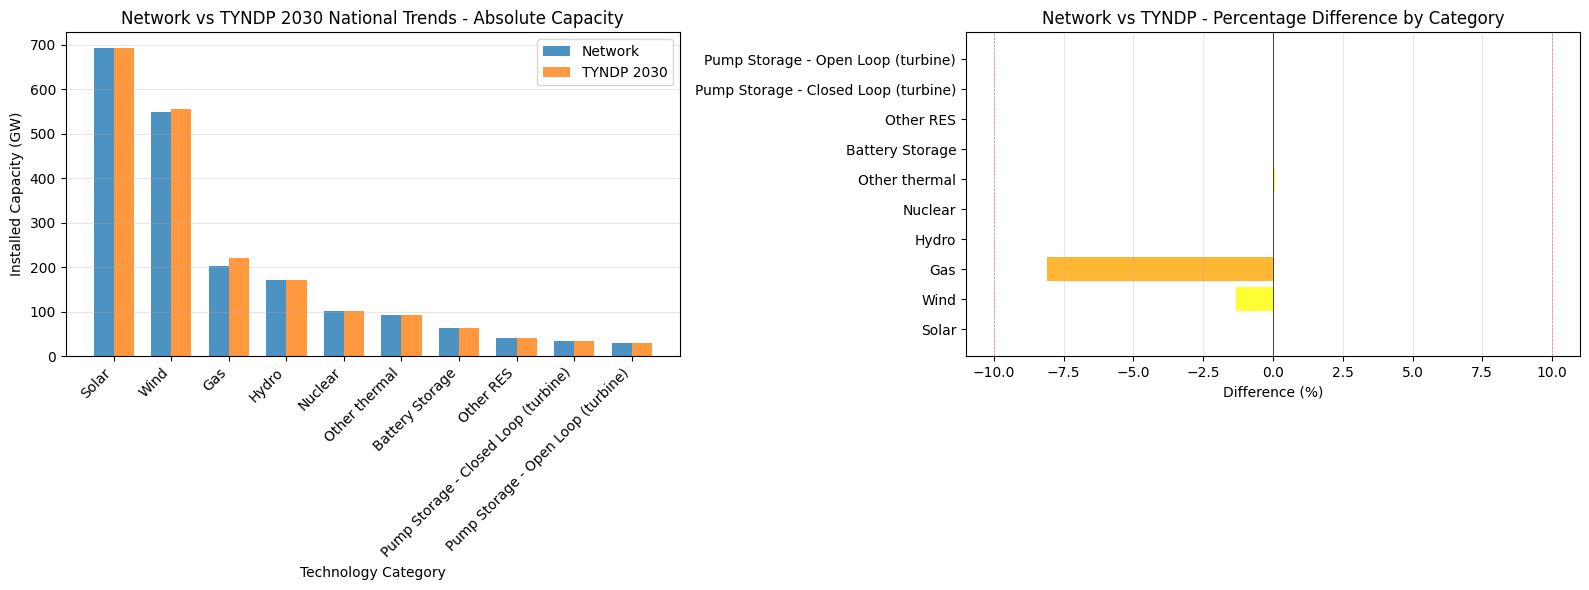

In [44]:
# Create validation visualizations
import matplotlib.pyplot as plt

# Exclude DSR for visualization
plot_data = total_summary[~total_summary['Category_Simple'].isin(['DSR Explicit', 'TOTAL', 'TOTAL (excl. DSR)'])].copy()
plot_data = plot_data.sort_values('Network', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Absolute capacities
x = range(len(plot_data))
width = 0.35
ax1.bar([i - width/2 for i in x], plot_data['Network'], width, label='Network', alpha=0.8)
ax1.bar([i + width/2 for i in x], plot_data['TYNDP'], width, label='TYNDP 2030', alpha=0.8)
ax1.set_xlabel('Technology Category')
ax1.set_ylabel('Installed Capacity (GW)')
ax1.set_title('Network vs TYNDP 2030 National Trends - Absolute Capacity')
ax1.set_xticks(x)
ax1.set_xticklabels(plot_data['Category_Simple'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Percentage difference
colors = ['red' if x < -10 else 'orange' if x < -5 else 'yellow' if abs(x) < 5 else 'lightgreen' if x < 10 else 'green' 
          for x in plot_data['Diff %']]
ax2.barh(plot_data['Category_Simple'], plot_data['Diff %'], color=colors, alpha=0.8)
ax2.set_xlabel('Difference (%)')
ax2.set_title('Network vs TYNDP - Percentage Difference by Category')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax2.axvline(x=-10, color='red', linestyle='--', linewidth=0.5, alpha=0.5)
ax2.axvline(x=10, color='red', linestyle='--', linewidth=0.5, alpha=0.5)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('capacity_validation.png', dpi=300, bbox_inches='tight')
plt.show()

## Phase 6: Add Time Series

**Goal**: Expand network to 8760 hours and add time-varying electricity demand for each bus.

**Steps**:
1. Set network snapshots to full year 2030 (8760 hours)
2. Prepare demand time series (shift 2009 profile to 2030)
3. Add loads with time series for each bus
4. Validate total demand matches TYNDP expectations

In [45]:
# Step 1: Set network snapshots to full year 2030
print("⏰ Setting network snapshots to full year 2030...")

# Create 8760 hourly snapshots for 2030
snapshots_2030 = pd.date_range('2030-01-01 00:00', periods=8760, freq='h')
network.set_snapshots(snapshots_2030)

print(f"✅ Network now has {len(network.snapshots)} snapshots")
print(f"   Start: {network.snapshots[0]}")
print(f"   End: {network.snapshots[-1]}")
print(f"\nSnapshot properties:")
print(f"   Duration: {len(network.snapshots)} hours")
print(f"   Days: {len(network.snapshots) / 24:.1f} days")

⏰ Setting network snapshots to full year 2030...
✅ Network now has 8760 snapshots
   Start: 2030-01-01 00:00:00
   End: 2030-12-31 23:00:00

Snapshot properties:
   Duration: 8760 hours
   Days: 365.0 days


In [46]:
# Step 2: Prepare demand time series
print("\n📊 Preparing electricity demand time series...")

# Inspect original demand data
print(f"Original demand data:")
print(f"   Shape: {electricity_demand.shape}")
print(f"   Index start: {electricity_demand.index[0]}")
print(f"   Index end: {electricity_demand.index[-1]}")
print(f"   Columns (buses): {electricity_demand.columns.tolist()}")

# Shift to 2030 (use 2009 profile as proxy)
demand_2030 = electricity_demand.copy()
demand_2030.index = pd.date_range('2030-01-01 00:00', periods=len(demand_2030), freq='h')

# Verify alignment
print(f"\nDemand 2030:")
print(f"   Shape: {demand_2030.shape}")
print(f"   Index start: {demand_2030.index[0]}")
print(f"   Index end: {demand_2030.index[-1]}")
print(f"\n✅ Demand time series prepared for {len(demand_2030.columns)} buses")


📊 Preparing electricity demand time series...
Original demand data:
   Shape: (8760, 63)
   Index start: 2009-01-01 00:00:00
   Index end: 2009-12-31 23:00:00
   Columns (buses): ['AL00', 'AT00', 'BA00', 'BE00', 'BG00', 'CH00', 'CY00', 'CZ00', 'DE00', 'DKE1', 'DZ00', 'DKW1', 'EE00', 'EG00', 'ES00', 'FI00', 'FR00', 'FR15', 'GE00', 'GR00', 'GR03', 'HR00', 'HU00', 'IL00', 'IE00', 'ITCA', 'ITCN', 'ITCS', 'ITN1', 'ITS1', 'ITSA', 'ITSI', 'LT00', 'LUB1', 'LUF1', 'LUG1', 'LY00', 'MD00', 'MA00', 'LV00', 'ME00', 'MK00', 'MT00', 'NL00', 'NOM1', 'NON1', 'NOS0', 'PL00', 'PS00', 'PT00', 'RO00', 'RS00', 'SE01', 'SE02', 'SE03', 'SE04', 'SI00', 'SK00', 'TN00', 'TR00', 'UA00', 'GB00', 'GBNI']

Demand 2030:
   Shape: (8760, 63)
   Index start: 2030-01-01 00:00:00
   Index end: 2030-12-31 23:00:00

✅ Demand time series prepared for 63 buses


In [47]:
print(buses["bus_id"].unique())
(len(buses["bus_id"].unique()))

['AL00' 'AT00' 'BA00' 'BE00' 'BG00' 'CH00' 'CY00' 'CZ00' 'DE00' 'DKE1'
 'DKW1' 'EE00' 'ES00' 'FI00' 'FR00' 'FR15' 'GB00' 'GBNI' 'GR00' 'GR03'
 'HR00' 'HU00' 'IE00' 'ITCA' 'ITCN' 'ITCS' 'ITN1' 'ITS1' 'ITSA' 'ITSI'
 'LT00' 'LUB1' 'LUF1' 'LUG1' 'LUV1' 'LV00' 'ME00' 'MK00' 'MT00' 'NL00'
 'NOM1' 'NON1' 'NOS0' 'PL00' 'PT00' 'RO00' 'RS00' 'SE01' 'SE02' 'SE03'
 'SE04' 'SI00' 'SK00' 'ITCO' 'ITVI']


['AL00' 'AT00' 'BA00' 'BE00' 'BG00' 'CH00' 'CY00' 'CZ00' 'DE00' 'DKE1'
 'DKW1' 'EE00' 'ES00' 'FI00' 'FR00' 'FR15' 'GB00' 'GBNI' 'GR00' 'GR03'
 'HR00' 'HU00' 'IE00' 'ITCA' 'ITCN' 'ITCS' 'ITN1' 'ITS1' 'ITSA' 'ITSI'
 'LT00' 'LUB1' 'LUF1' 'LUG1' 'LUV1' 'LV00' 'ME00' 'MK00' 'MT00' 'NL00'
 'NOM1' 'NON1' 'NOS0' 'PL00' 'PT00' 'RO00' 'RS00' 'SE01' 'SE02' 'SE03'
 'SE04' 'SI00' 'SK00' 'ITCO' 'ITVI']


55

In [50]:
print(len(network.buses[~network.buses.index.str.contains("-")]))
# display(network.buses[~network.buses.index.str.contains("-")])

print(len(network.buses))
display(network.buses)


55
132


,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,country
name,,,,,,,,,,,,,,
AL00,380.0,,20.036884,41.117588,AC,,,1.0,0.0,inf,PQ,,,AL
AT00,380.0,,14.822183,47.668898,AC,,,1.0,0.0,inf,PQ,,,AT
BA00,380.0,,17.867837,43.982016,AC,,,1.0,0.0,inf,PQ,,,BA
BE00,380.0,,4.967931,50.470635,AC,,,1.0,0.0,inf,PQ,,,BE
BG00,380.0,,25.323948,42.668760,AC,,,1.0,0.0,inf,PQ,,,BG
CH00,380.0,,8.416156,46.797090,AC,,,1.0,0.0,inf,PQ,,,CH
CY00,380.0,,33.008947,34.944963,AC,,,1.0,0.0,inf,PQ,,,CY
CZ00,380.0,,15.663683,49.752662,AC,,,1.0,0.0,inf,PQ,,,CZ
DE00,380.0,,10.113400,51.109915,AC,,,1.0,0.0,inf,PQ,,,DE


In [52]:
# Step 3: Add loads with time series
print("\n🏭 Adding loads to network...")

added_loads = 0
missing_demand = []

for bus in network.buses.index:
    # Skip storage buses (they don't have demand)
    if '-' in bus and any(storage in bus for storage in ['battery', 'hydro-phs']):
        continue
    
    # Check if demand data exists for this bus
    if bus in demand_2030.columns:
        # Get time series
        demand_ts = demand_2030[bus].values
        
        # Add load to network
        network.add(
            "Load",
            name=f"{bus}-load",
            bus=bus,
            p_set=demand_ts  # Time series (8760 values)
        )
        added_loads += 1
    else:
        missing_demand.append(bus)
        # Add minimal constant load for buses without data
        network.add(
            "Load",
            name=f"{bus}-load",
            bus=bus,
            p_set=100.0  # 100 MW constant
        )

print(f"✅ Added {added_loads} loads with time series demand")
if missing_demand:
    print(f"⚠️  {len(missing_demand)} buses without demand data (using 100 MW constant):")
    print(f"   {missing_demand}")

print(f"\nTotal loads in network: {len(network.loads)}")

In [53]:
# Step 4: Validate demand
print("\n📈 Validating electricity demand...")

# Total demand statistics
total_demand_ts = network.loads_t.p_set.sum(axis=1)  # Sum across all loads at each timestep

print(f"\nDemand statistics:")
print(f"   Mean: {total_demand_ts.mean():.0f} MW")
print(f"   Min: {total_demand_ts.min():.0f} MW")
print(f"   Max: {total_demand_ts.max():.0f} MW")
print(f"   Total annual energy: {total_demand_ts.sum() / 1000:.0f} GWh")

# Sample demand profile for a major country
print(f"\nSample demand profile for DE00 (Germany):")
if 'DE00-load' in network.loads.index:
    de_demand = network.loads_t.p_set['DE00-load']
    print(f"   Mean: {de_demand.mean():.0f} MW")
    print(f"   Min: {de_demand.min():.0f} MW")
    print(f"   Max: {de_demand.max():.0f} MW")
    print(f"\nFirst 24 hours:")
    print(de_demand.head(24))

print("\n✅ Phase 6 complete: Time series demand added to network")

## Phase 6.2: Add Renewable Profiles

**Goal**: Add time-varying capacity factors for renewable generators (wind, solar).

**Data**: Wind onshore/offshore, solar utility/rooftop capacity factor profiles (0-1).

**Next**: Apply these profiles to renewable generators' `p_max_pu`.

In [59]:
# Step 3: Apply availability profiles for renewable generators
print("Applying renewable availability profiles...")

# Shift renewable profiles to 2030
wind_onshore_2030 = wind_onshore.copy()
wind_onshore_2030.index = pd.date_range('2030-01-01', periods=len(wind_onshore_2030), freq='h')

wind_offshore_2030 = wind_offshore.copy()
wind_offshore_2030.index = pd.date_range('2030-01-01', periods=len(wind_offshore_2030), freq='h')

solar_utility_2030 = solar_utility.copy()
solar_utility_2030.index = pd.date_range('2030-01-01', periods=len(solar_utility_2030), freq='h')

solar_rooftop_2030 = solar_rooftop.copy()
solar_rooftop_2030.index = pd.date_range('2030-01-01', periods=len(solar_rooftop_2030), freq='h')

# Apply profiles to generators
applied_renewables = {"onwind": 0, "offwind": 0, "solar-pv-utility": 0, "solar-pv-rooftop": 0}
for gen_name in network.generators.index:
    bus = network.generators.loc[gen_name, 'bus']
    carrier = network.generators.loc[gen_name, 'carrier']
    
    if carrier == 'onwind' and bus in wind_onshore_2030.columns:
        network.generators_t.p_max_pu[gen_name] = wind_onshore_2030[bus].values
        applied_renewables['onwind'] += 1
    elif carrier == 'offwind' and bus in wind_offshore_2030.columns:
        network.generators_t.p_max_pu[gen_name] = wind_offshore_2030[bus].values
        applied_renewables['offwind'] += 1
    elif carrier == 'solar-pv-utility' and bus in solar_utility_2030.columns:
        network.generators_t.p_max_pu[gen_name] = solar_utility_2030[bus].values
        applied_renewables['solar-pv-utility'] += 1
    elif carrier == 'solar-pv-rooftop' and bus in solar_rooftop_2030.columns:
        network.generators_t.p_max_pu[gen_name] = solar_rooftop_2030[bus].values
        applied_renewables['solar-pv-rooftop'] += 1
    else:
        # For non-variable renewables and thermal, set constant availability
        network.generators_t.p_max_pu[gen_name] = 1.0

print(f"✅ Applied availability profiles to {applied_renewables} renewable generators")
print(f"\nSample wind profile for DE00:")
print(network.generators_t.p_max_pu['DE00-onwind'].head())

Applying renewable availability profiles...
✅ Applied availability profiles to {'onwind': 49, 'offwind': 0, 'solar-pv-utility': 40, 'solar-pv-rooftop': 36} renewable generators

Sample wind profile for DE00:
snapshot
2030-01-01 00:00:00    0.066001
2030-01-01 01:00:00    0.079850
2030-01-01 02:00:00    0.092935
2030-01-01 03:00:00    0.102895
2030-01-01 04:00:00    0.117694
Freq: h, Name: DE00-onwind, dtype: float64


In [64]:
# Step 4: Apply thermal generator availability
print("Applying thermal generator availability...")

# Shift thermal availability to 2030
thermal_avail_2030 = thermal_avail.copy()
thermal_avail_2030.index = pd.date_range('2030-01-01', periods=len(thermal_avail_2030), freq='h')

# Track what was applied per bus
bus_carriers_applied = {}
applied_thermal = 0

for gen_name in network.generators.index:
    bus = network.generators.loc[gen_name, 'bus']
    carrier = network.generators.loc[gen_name, 'carrier']
    
    # Apply to conventional/thermal generators only (not RES)
    if carrier in CONVENTIONAL_CARRIERS:
        if bus in thermal_avail_2030.columns:
            # Apply thermal availability profile
            network.generators_t.p_max_pu[gen_name] = thermal_avail_2030[bus].values
            applied_thermal += 1
            
            # Track by bus
            if bus not in bus_carriers_applied:
                bus_carriers_applied[bus] = []
            bus_carriers_applied[bus].append(carrier)
        else:
            # Default thermal availability (95%)
            network.generators_t.p_max_pu[gen_name] = 0.95

print(f"Applied thermal availability to {applied_thermal} conventional generators")



Applying thermal generator availability...
Applied thermal availability to 265 conventional generators


In [65]:
# Create summary table
bus_summary = []
for bus, carriers in sorted(bus_carriers_applied.items()):
    bus_summary.append({
        'Bus': bus,
        'Carriers': ', '.join(sorted(set(carriers))),
        'Count': len(carriers)
    })

thermal_summary_df = pd.DataFrame(bus_summary)
print(f"\n📊 Thermal availability applied by bus:")
print(thermal_summary_df.to_string(index=False))

print(f"\nSample thermal availability for DE00 (nuclear):")
if 'DE00-nuclear' in network.generators.index:
    print(network.generators_t.p_max_pu['DE00-nuclear'].head())


📊 Thermal availability applied by bus:
 Bus                                                                                 Carriers  Count
AL00                                                                     gas, hydro-reservoir      2
AT00              electrolyser, gas, hydro-pondage, hydro-reservoir, oil-light, other-thermal      8
BA00                                                  hydro-pondage, hydro-reservoir, lignite      3
BE00                               coal, electrolyser, gas, nuclear, oil-heavy, other-thermal      8
BG00                                     electrolyser, gas, hydro-reservoir, lignite, nuclear      7
CH00                                    electrolyser, hydro-reservoir, nuclear, other-thermal      4
CY00                                                                gas, oil-heavy, oil-light      4
CZ00            coal, electrolyser, gas, h2, hydro-reservoir, lignite, nuclear, other-thermal     10
DE00                         electrolyser, gas, h2,

In [1]:
# Step 5: Apply hydro run-of-river capacity factors
print("💧 Applying hydro run-of-river capacity factors...")
print(f"DEBUG: HYDRO_ROR_CARRIERS = {HYDRO_ROR_CARRIERS}")

# Shift hydro RoR to 2030
hydro_ror_2030 = hydro_ror.copy()
hydro_ror_2030.index = pd.date_range('2030-01-01', periods=len(hydro_ror_2030), freq='h')

# Track what was applied per bus
bus_hydro_ror_applied = {}
applied_hydro_ror = 0

# DEBUG: Check what carriers we have
hydro_carriers_found = []

for gen_name in network.generators.index:
    bus = network.generators.loc[gen_name, 'bus']
    carrier = network.generators.loc[gen_name, 'carrier']
    
    # DEBUG: Track hydro carriers
    if 'hydro' in carrier:
        if carrier not in hydro_carriers_found:
            hydro_carriers_found.append(carrier)
    
    # Apply only to run-of-river hydro (non-dispatchable)
    if carrier in HYDRO_ROR_CARRIERS:
        country = network.buses.loc[bus, 'country']
        if country in hydro_ror_2030.columns:
            # Apply hydro RoR profile (normalized by capacity)
            # hydro_ror_2030 is in MW, we need it as p.u. (fraction of capacity)
            capacity = network.generators.loc[gen_name, 'p_nom']
            if capacity > 0:
                cf_profile = hydro_ror_2030[country].values / capacity
                # Clip to [0, 1] range
                network.generators_t.p_max_pu[gen_name] = cf_profile.clip(0, 1)
                applied_hydro_ror += 1
                
                # Track by bus
                if bus not in bus_hydro_ror_applied:
                    bus_hydro_ror_applied[bus] = 0
                bus_hydro_ror_applied[bus] += 1
        else:
            # Default constant availability if no profile data
            network.generators_t.p_max_pu[gen_name] = 0.5

print(f"DEBUG: Hydro carriers found in network: {hydro_carriers_found}")
print(f"✅ Applied hydro RoR capacity factors to {applied_hydro_ror} generators")

# Create summary table
if bus_hydro_ror_applied:
    hydro_ror_summary = []
    for bus, count in sorted(bus_hydro_ror_applied.items()):
        hydro_ror_summary.append({
            'Bus': bus,
            'Carrier': 'hydro-ror',
            'Count': count
        })
    
    hydro_ror_df = pd.DataFrame(hydro_ror_summary)
    print(f"\n📊 Hydro RoR capacity factors applied by bus:")
    print(hydro_ror_df.to_string(index=False))
else:
    print("⚠️  No hydro-ror generators found in network")


💧 Applying hydro run-of-river capacity factors...


NameError: name 'HYDRO_ROR_CARRIERS' is not defined

In [57]:
# Step 6: Apply hydro reservoir inflows for storage units
print("🌊 Applying hydro reservoir and PHS inflows to storage...")

# Shift hydro inflows to 2030
hydro_reservoir_2030 = hydro_reservoir.copy()
hydro_reservoir_2030.index = pd.date_range('2030-01-01', periods=len(hydro_reservoir_2030), freq='h')

hydro_pondage_2030 = hydro_pondage.copy()
hydro_pondage_2030.index = pd.date_range('2030-01-01', periods=len(hydro_pondage_2030), freq='h')

hydro_ps_open_2030 = hydro_ps_open.copy()
hydro_ps_open_2030.index = pd.date_range('2030-01-01', periods=len(hydro_ps_open_2030), freq='h')

applied_hydro_storage = 0
for storage_name in network.storage_units.index:
    bus = network.storage_units.loc[storage_name, 'bus']
    carrier = network.storage_units.loc[storage_name, 'carrier']
    country = network.buses.loc[bus, 'country']
    
    if carrier == 'hydro-reservoir' and country in hydro_reservoir_2030.columns:
        # Apply reservoir inflows
        network.storage_units_t.inflow[storage_name] = hydro_reservoir_2030[country].values
        applied_hydro_storage += 1
    elif carrier == 'hydro-pondage' and country in hydro_pondage_2030.columns:
        network.storage_units_t.inflow[storage_name] = hydro_pondage_2030[country].values
        applied_hydro_storage += 1
    elif carrier in ['hydro-phs', 'hydro-phs-pure'] and country in hydro_ps_open_2030.columns:
        network.storage_units_t.inflow[storage_name] = hydro_ps_open_2030[country].values
        applied_hydro_storage += 1
    else:
        # No natural inflow for batteries and unknown storage
        network.storage_units_t.inflow[storage_name] = 0.0

print(f"✅ Applied inflows to {applied_hydro_storage} hydro storage units")

🌊 Applying hydro reservoir and PHS inflows to storage...
✅ Applied inflows to 0 hydro storage units


In [58]:
# Summary of time series application
print("=" * 60)
print("TIME SERIES APPLICATION SUMMARY")
print("=" * 60)
print(f"\n✅ Network now has {len(network.snapshots)} hourly snapshots for 2030")
print(f"\n📊 Time series applied:")
print(f"   Loads: {len([l for l in network.loads.index if l in network.loads_t.p_set.columns])} / {len(network.loads)}")
print(f"   Generators (p_max_pu): {len([g for g in network.generators.index if g in network.generators_t.p_max_pu.columns])} / {len(network.generators)}")
print(f"   Storage (inflow): {len([s for s in network.storage_units.index if s in network.storage_units_t.inflow.columns])} / {len(network.storage_units)}")

print(f"\n📈 Sample data validation:")
print(f"   Total load (mean): {network.loads_t.p_set.sum(axis=1).mean():.0f} MW")
print(f"   Total load (max): {network.loads_t.p_set.sum(axis=1).max():.0f} MW")
print(f"   Total load (min): {network.loads_t.p_set.sum(axis=1).min():.0f} MW")

print(f"\n⚠️  Network is now ready for optimization!")

TIME SERIES APPLICATION SUMMARY

✅ Network now has 8760 hourly snapshots for 2030

📊 Time series applied:
   Loads: 52 / 55
   Generators (p_max_pu): 503 / 503
   Storage (inflow): 0 / 0

📈 Sample data validation:
   Total load (mean): 450624 MW
   Total load (max): 713978 MW
   Total load (min): 271057 MW

⚠️  Network is now ready for optimization!


In [ ]:
# Save the network before optimization
output_file = "tyndp2024_network_2030_preoptimization.nc"
network.export_to_netcdf(output_file)
print(f"💾 Network saved to: {output_file}")
print(f"   File size: {os.path.getsize(output_file) / 1024 / 1024:.1f} MB")

INFO:pypsa.network.io:Exported network 'TYNDP2024_Electricity_2030'saved to 'tyndp2024_network_2030_preoptimization.nc contains: links, generators, loads, buses, storage_units


💾 Network saved to: tyndp2024_network_2030_preoptimization.nc
   File size: 13.4 MB


## Phase 7: Optimization

Run linear optimal power flow (LOPF) to optimize network operation.

In [ ]:
# Check available solvers
print("🔍 Checking available optimization solvers...")
print("\nRecommended solvers (in order of preference):")
print("  1. Gurobi (commercial, fastest) - requires license")
print("  2. CPLEX (commercial, fast) - requires license")
print("  3. HiGHS (open-source, good performance)")
print("  4. GLPK (open-source, slower)")

# Try to detect which solvers are available
try:
    import highspy
    print("\n✅ HiGHS solver available")
    default_solver = 'highs'
except ImportError:
    print("\n⚠️  HiGHS not installed. Install with: pip install highspy")
    default_solver = 'glpk'

print(f"\n📊 Default solver for this session: {default_solver}")

🔍 Checking available optimization solvers...

Recommended solvers (in order of preference):
  1. Gurobi (commercial, fastest) - requires license
  2. CPLEX (commercial, fast) - requires license
  3. HiGHS (open-source, good performance)
  4. GLPK (open-source, slower)

✅ HiGHS solver available

📊 Default solver for this session: highs


### Option 1: Test Optimization (1 Week)

Run a quick test on the first week of January 2030 to validate the model.

In [ ]:
# Create a test network for 1 week (168 hours)
print("🧪 Creating test network for 1 week optimization...")

# Create a copy of the network with only first week
network_test = network.copy()
test_snapshots = pd.date_range('2030-01-01', periods=168, freq='h')
network_test.set_snapshots(test_snapshots)

# Copy time series data for the test period
for load in network_test.loads.index:
    if load in network.loads_t.p_set.columns:
        network_test.loads_t.p_set[load] = network.loads_t.p_set[load].iloc[:168].values

for gen in network_test.generators.index:
    if gen in network.generators_t.p_max_pu.columns:
        network_test.generators_t.p_max_pu[gen] = network.generators_t.p_max_pu[gen].iloc[:168].values

for storage in network_test.storage_units.index:
    if storage in network.storage_units_t.inflow.columns:
        network_test.storage_units_t.inflow[storage] = network.storage_units_t.inflow[storage].iloc[:168].values

print(f"✅ Test network created with {len(network_test.snapshots)} snapshots")
print(f"   Period: {network_test.snapshots[0]} to {network_test.snapshots[-1]}")

🧪 Creating test network for 1 week optimization...
✅ Test network created with 168 snapshots
   Period: 2030-01-01 00:00:00 to 2030-01-07 23:00:00


In [ ]:
# Run test optimization (1 week)
import time

print("🚀 Starting test optimization (1 week)...")
print("   This may take a few minutes...")
start_time = time.time()

try:
    network_test.optimize(
        solver_name=default_solver,
        solver_logfile='optimization_test_1week.log'
    )
    
    elapsed_time = time.time() - start_time
    
    print(f"\n✅ Test optimization completed!")
    print(f"   Time elapsed: {elapsed_time:.1f} seconds ({elapsed_time/60:.1f} minutes)")
    print(f"   Objective (total cost): €{network_test.objective:,.0f}")
    print(f"   Status: {network_test.status}")
    
    # Quick validation
    total_generation = network_test.generators_t.p.sum().sum()
    total_load = network_test.loads_t.p.sum().sum()
    total_storage_dispatch = network_test.storage_units_t.p.sum().sum()
    
    print(f"\n📊 Quick validation:")
    print(f"   Total generation: {total_generation:,.0f} MWh")
    print(f"   Total load: {total_load:,.0f} MWh")
    print(f"   Balance error: {abs(total_generation - total_load):,.0f} MWh ({abs(total_generation - total_load)/total_load*100:.2f}%)")
    
    # Save test results
    network_test.export_to_netcdf("tyndp2024_network_2030_optimized_1week.nc")
    print(f"\n💾 Test results saved to: tyndp2024_network_2030_optimized_1week.nc")
    
except Exception as e:
    print(f"\n❌ Optimization failed: {str(e)}")
    print("   Check the log file for details: optimization_test_1week.log")

Index(['AL00-GR00-DC', 'AL00-ME00-DC', 'AL00-MK00-DC', 'AL00-RS00-DC',
       'AT00-CH00-DC', 'AT00-CZ00-DC', 'AT00-DE00-DC', 'AT00-HU00-DC',
       'AT00-ITN1-DC', 'AT00-SI00-DC',
       ...
       'SE04-PL00-DC', 'SE04-SE03-DC', 'SI00-AT00-DC', 'SI00-HR00-DC',
       'SI00-HU00-DC', 'SI00-ITN1-DC', 'SK00-AT00-DC', 'SK00-CZ00-DC',
       'SK00-HU00-DC', 'SK00-PL00-DC'],
      dtype='object', name='Link', length=219)


🚀 Starting test optimization (1 week)...
   This may take a few minutes...


Index(['AL00-hydro-ror', 'AL00-onwind', 'AL00-solar-pv-utility', 'AL00-gas',
       'AT00-hydro-ror', 'AT00-onwind', 'AT00-solar-pv-utility',
       'AT00-solar-pv-rooftop', 'AT00-gas', 'AT00-oil-light',
       ...
       'SK00-hydro-ror', 'SK00-onwind', 'SK00-solar-pv-utility',
       'SK00-uranium', 'SK00-coal', 'SK00-lignite', 'SK00-gas',
       'SK00-oil-heavy', 'SK00-chp', 'SK00-other-res'],
      dtype='object', name='Generator', length=365)
Index(['AL00', 'AT00', 'BA00', 'BE00', 'BG00', 'CH00', 'CY00', 'CZ00', 'DE00',
       'DKE1', 'DKW1', 'EE00', 'ES00', 'FI00', 'FR00', 'FR15', 'GB00', 'GBNI',
       'GR00', 'GR03', 'HR00', 'HU00', 'IE00', 'ITCA', 'ITCN', 'ITCS', 'ITN1',
       'ITS1', 'ITSA', 'ITSI', 'LT00', 'LUB1', 'LUF1', 'LUG1', 'LUV1', 'LV00',
       'ME00', 'MK00', 'MT00', 'NL00', 'NOM1', 'NON1', 'NOS0', 'PL00', 'PT00',
       'RO00', 'RS00', 'SE01', 'SE02', 'SE03', 'SE04', 'SI00', 'SK00', 'ITCO',
       'ITVI'],
      dtype='object', name='Bus')
Index(['AL00-hydro-reser

ERROR:   getOptionIndex: Option "solver_logfile" is unknown
Running HiGHS 1.13.0 (git hash: 1bce6d5): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-4kb3kp01 has 346584 rows; 158592 cols; 572880 nonzeros
Coefficient ranges:
  Matrix  [3e-02, 1e+00]
  Cost    [1e+00, 2e+02]
  Bound   [0e+00, 0e+00]
  RHS     [3e-06, 4e+07]
Presolving model
Problem status detected on presolve: Infeasible
Model name          : linopy-problem-4kb3kp01
Model status        : Infeasible
Objective value     :  0.0000000000e+00
HiGHS run time      :          0.10

✅ Test optimization completed!
   Time elapsed: 4.7 seconds (0.1 minutes)

❌ Optimization failed: unsupported format string passed to NoneType.__format__
   Check the log file for details: optimization_test_1week.log


In [ ]:
# Diagnose why the network is infeasible
print("🔍 DIAGNOSING NETWORK INFEASIBILITY")
print("=" * 60)

# Check 1: Total generation capacity vs load
total_gen_capacity = network_test.generators['p_nom'].sum()
total_storage_capacity = network_test.storage_units['p_nom'].sum()
mean_load = network_test.loads_t.p_set.sum(axis=1).mean()
peak_load = network_test.loads_t.p_set.sum(axis=1).max()

print(f"\n1️⃣  CAPACITY BALANCE:")
print(f"   Total generator capacity: {total_gen_capacity:,.0f} MW")
print(f"   Total storage capacity: {total_storage_capacity:,.0f} MW")
print(f"   Mean load: {mean_load:,.0f} MW")
print(f"   Peak load: {peak_load:,.0f} MW")
print(f"   Generation coverage: {total_gen_capacity/peak_load*100:.1f}% of peak")

if total_gen_capacity < peak_load * 0.9:
    print("   ⚠️  WARNING: Insufficient generation capacity!")

# Check 2: Isolated buses (no generators or connections)
print(f"\n2️⃣  NETWORK CONNECTIVITY:")
buses_with_generators = set(network_test.generators['bus'].unique())
buses_with_storage = set(network_test.storage_units['bus'].unique())
buses_with_supply = buses_with_generators.union(buses_with_storage)
all_buses = set(network_test.buses.index)
buses_without_supply = all_buses - buses_with_supply

print(f"   Total buses: {len(all_buses)}")
print(f"   Buses with generators: {len(buses_with_generators)}")
print(f"   Buses with storage: {len(buses_with_storage)}")
print(f"   Buses without supply: {len(buses_without_supply)}")

if len(buses_without_supply) > 0:
    print(f"   ⚠️  WARNING: {len(buses_without_supply)} buses have no generation or storage!")
    print(f"   Example buses: {list(buses_without_supply)[:5]}")

# Check 3: Time series data issues
print(f"\n3️⃣  TIME SERIES DATA:")
print(f"   Load time series: {network_test.loads_t.p_set.shape}")
print(f"   Any NaN in loads? {network_test.loads_t.p_set.isna().any().any()}")
print(f"   Any negative loads? {(network_test.loads_t.p_set < 0).any().any()}")

print(f"\n   Generator availability (p_max_pu): {network_test.generators_t.p_max_pu.shape}")
print(f"   Any NaN in p_max_pu? {network_test.generators_t.p_max_pu.isna().any().any()}")
print(f"   Any negative p_max_pu? {(network_test.generators_t.p_max_pu < 0).any().any()}")

# Check 4: Generator availability for dispatchable units
print(f"\n4️⃣  DISPATCHABLE GENERATION:")
dispatchable = ['uranium', 'coal', 'lignite', 'gas', 'oil-light', 'oil-heavy']
for carrier in dispatchable:
    gens = network_test.generators[network_test.generators.carrier == carrier]
    if len(gens) > 0:
        capacity = gens['p_nom'].sum()
        # Check if any have p_max_pu set
        has_availability = any([g in network_test.generators_t.p_max_pu.columns for g in gens.index])
        if has_availability:
            avg_avail = network_test.generators_t.p_max_pu[gens.index].mean().mean()
            print(f"   {carrier:15s}: {capacity:8,.0f} MW (avg avail: {avg_avail*100:.1f}%)")
        else:
            print(f"   {carrier:15s}: {capacity:8,.0f} MW (no availability constraint)")

# Check 5: Renewable availability
print(f"\n5️⃣  RENEWABLE GENERATION:")
renewables = ['onwind', 'offwind', 'solar-pv-utility', 'solar-pv-rooftop']
for carrier in renewables:
    gens = network_test.generators[network_test.generators.carrier == carrier]
    if len(gens) > 0:
        capacity = gens['p_nom'].sum()
        avg_avail = network_test.generators_t.p_max_pu[gens.index].mean().mean()
        max_avail = network_test.generators_t.p_max_pu[gens.index].max().max()
        print(f"   {carrier:20s}: {capacity:8,.0f} MW (avg: {avg_avail*100:.1f}%, max: {max_avail*100:.1f}%)")

# Check 6: Network links
print(f"\n6️⃣  TRANSMISSION:")
print(f"   Total HVDC links: {len(network_test.links)}")
print(f"   Total transmission capacity: {network_test.links['p_nom'].sum():,.0f} MW")

print("\n" + "=" * 60)

🔍 DIAGNOSING NETWORK INFEASIBILITY

1️⃣  CAPACITY BALANCE:
   Total generator capacity: 1,565,297 MW
   Total storage capacity: 238,029 MW
   Mean load: 532,067 MW
   Peak load: 640,541 MW
   Generation coverage: 244.4% of peak

2️⃣  NETWORK CONNECTIVITY:
   Total buses: 55
   Buses with generators: 50
   Buses with storage: 47
   Buses without supply: 4
   ⚠️  WARNING: 4 buses have no generation or storage!
   Example buses: ['LUF1', 'ITVI', 'ITCO', 'LUB1']

3️⃣  TIME SERIES DATA:
   Load time series: (168, 55)
   Any NaN in loads? False
   Any negative loads? False

   Generator availability (p_max_pu): (168, 365)
   Any NaN in p_max_pu? False
   Any negative p_max_pu? False

4️⃣  DISPATCHABLE GENERATION:
   uranium        :  101,795 MW (avg avail: 80.0%)
   coal           :    9,572 MW (avg avail: 80.0%)
   lignite        :   14,947 MW (avg avail: 80.0%)
   gas            :   55,677 MW (avg avail: 80.0%)
   oil-light      :    5,242 MW (avg avail: 80.0%)
   oil-heavy      :    1,042

### Fix: Add Slack Generators

Some buses have no generation capacity. We'll add "slack generators" with high marginal cost to ensure feasibility. These act as emergency backup and will only be used if absolutely necessary.

In [ ]:
# Add slack generators to ALL buses to ensure feasibility
# These have very high marginal cost (10000 €/MWh) so they'll only be used as last resort

print("🔧 Adding slack generators to ensure feasibility...")

# Get peak load per bus to size slack generators
peak_load_per_bus = network_test.loads_t.p_set.max()

added_slack = 0
for bus in network_test.buses.index:
    # Size slack generator as 1.5x peak load at that bus (or 1000 MW minimum)
    slack_capacity = max(peak_load_per_bus.get(bus, 0) * 1.5, 1000)
    
    slack_name = f"{bus}-slack"
    
    # Add to full network (not just test)
    network.add("Generator",
                name=slack_name,
                bus=bus,
                carrier='slack',
                p_nom=slack_capacity,
                marginal_cost=10000,  # Very expensive - only used if necessary
                efficiency=1.0)
    
    added_slack += 1

print(f"✅ Added {added_slack} slack generators to main network")

# Now recreate test network with slack generators
print("\n🧪 Recreating test network with slack generators...")

network_test = network.copy()
test_snapshots = pd.date_range('2030-01-01', periods=168, freq='h')
network_test.set_snapshots(test_snapshots)

# Copy time series data
for load in network_test.loads.index:
    if load in network.loads_t.p_set.columns:
        network_test.loads_t.p_set[load] = network.loads_t.p_set[load].iloc[:168].values

for gen in network_test.generators.index:
    if gen in network.generators_t.p_max_pu.columns:
        network_test.generators_t.p_max_pu[gen] = network.generators_t.p_max_pu[gen].iloc[:168].values
    elif network_test.generators.loc[gen, 'carrier'] == 'slack':
        # Slack generators always available
        network_test.generators_t.p_max_pu[gen] = 1.0

for storage in network_test.storage_units.index:
    if storage in network.storage_units_t.inflow.columns:
        network_test.storage_units_t.inflow[storage] = network.storage_units_t.inflow[storage].iloc[:168].values

print(f"✅ Test network recreated with {len(network_test.snapshots)} snapshots")
print(f"   Total generators: {len(network_test.generators)} (including {(network_test.generators.carrier == 'slack').sum()} slack)")
print(f"   Total capacity: {network_test.generators['p_nom'].sum():,.0f} MW")

🔧 Adding slack generators to ensure feasibility...
✅ Added 55 slack generators to main network

🧪 Recreating test network with slack generators...
✅ Test network recreated with 168 snapshots
   Total generators: 420 (including 55 slack)
   Total capacity: 1,620,297 MW


In [ ]:
# Run test optimization with fixed network
import time

print("🚀 Starting test optimization (1 week) - ATTEMPT 2...")
print("   This may take a few minutes...")
start_time = time.time()

try:
    network_test.optimize(
        solver_name=default_solver
    )
    
    elapsed_time = time.time() - start_time
    
    print(f"\n✅ Test optimization completed!")
    print(f"   Time elapsed: {elapsed_time:.1f} seconds ({elapsed_time/60:.1f} minutes)")
    print(f"   Objective (total cost): €{network_test.objective:,.0f}")
    
    # Check slack generator usage
    slack_gens = network_test.generators[network_test.generators.carrier == 'slack'].index
    slack_generation = network_test.generators_t.p[slack_gens].sum().sum()
    total_generation = network_test.generators_t.p.sum().sum()
    
    print(f"\n📊 Quick validation:")
    print(f"   Total generation: {total_generation:,.0f} MWh")
    print(f"   Slack generation: {slack_generation:,.0f} MWh ({slack_generation/total_generation*100:.2f}%)")
    
    if slack_generation > total_generation * 0.01:
        print(f"   ⚠️  Warning: Slack generators provided {slack_generation/total_generation*100:.1f}% of generation!")
        print(f"      This indicates insufficient real generation capacity.")
    else:
        print(f"   ✅ Good: Minimal slack usage (<1%)")
    
    total_load = network_test.loads_t.p.sum().sum()
    print(f"   Total load: {total_load:,.0f} MWh")
    print(f"   Balance error: {abs(total_generation - total_load):,.0f} MWh")
    
    # Save test results
    network_test.export_to_netcdf("tyndp2024_network_2030_optimized_1week.nc")
    print(f"\n💾 Test results saved to: tyndp2024_network_2030_optimized_1week.nc")
    
except Exception as e:
    print(f"\n❌ Optimization failed: {str(e)}")
    import traceback
    traceback.print_exc()

Index(['AL00-GR00-DC', 'AL00-ME00-DC', 'AL00-MK00-DC', 'AL00-RS00-DC',
       'AT00-CH00-DC', 'AT00-CZ00-DC', 'AT00-DE00-DC', 'AT00-HU00-DC',
       'AT00-ITN1-DC', 'AT00-SI00-DC',
       ...
       'SE04-PL00-DC', 'SE04-SE03-DC', 'SI00-AT00-DC', 'SI00-HR00-DC',
       'SI00-HU00-DC', 'SI00-ITN1-DC', 'SK00-AT00-DC', 'SK00-CZ00-DC',
       'SK00-HU00-DC', 'SK00-PL00-DC'],
      dtype='object', name='Link', length=219)
Index(['AL00-hydro-ror', 'AL00-onwind', 'AL00-solar-pv-utility', 'AL00-gas',
       'AT00-hydro-ror', 'AT00-onwind', 'AT00-solar-pv-utility',
       'AT00-solar-pv-rooftop', 'AT00-gas', 'AT00-oil-light',
       ...
       'RO00-slack', 'RS00-slack', 'SE01-slack', 'SE02-slack', 'SE03-slack',
       'SE04-slack', 'SI00-slack', 'SK00-slack', 'ITCO-slack', 'ITVI-slack'],
      dtype='object', name='Generator', length=420)
Index(['AL00', 'AT00', 'BA00', 'BE00', 'BG00', 'CH00', 'CY00', 'CZ00', 'DE00',
       'DKE1', 'DKW1', 'EE00', 'ES00', 'FI00', 'FR00', 'FR15', 'GB00', 'GBNI',

🚀 Starting test optimization (1 week) - ATTEMPT 2...
   This may take a few minutes...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 130.06it/s]
INFO:linopy.io: Writing time: 0.75s


Running HiGHS 1.13.0 (git hash: 1bce6d5): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-nctpps18 has 365064 rows; 167832 cols; 600600 nonzeros
Coefficient ranges:
  Matrix  [3e-02, 1e+00]
  Cost    [1e+00, 1e+04]
  Bound   [0e+00, 0e+00]
  RHS     [3e-06, 4e+07]
Presolving model
29377 rows, 158308 cols, 254648 nonzeros  0s
Dependent equations search running on 29377 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.01s (limit = 1000.00s)
29377 rows, 137059 cols, 233445 nonzeros  1s
Presolve reductions: rows 29377(-335687); columns 137059(-30773); nonzeros 233445(-367155) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 1.1s
      16802     7.2791486384e+06 Pr: 17825(9.18771e+08); Du: 0(2.38014e-06) 6.2s
      30413     3.4114444499e+08 Pr: 16930(1.30635e+08); Du: 0(1.09752e-06) 11.2s
      43379     5.5339395444e+08 Pr:

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 167832 primals, 365064 duals
Objective: 8.48e+08
Solver model: available
Solver message: Optimal




Model name          : linopy-problem-nctpps18
Model status        : Optimal
Simplex   iterations: 57662
Objective value     :  8.4805458753e+08
P-D objective error :  4.6317137436e-14
HiGHS run time      :         19.81


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.
INFO:pypsa.network.io:Exported network 'TYNDP2024_Electricity_2030'saved to 'tyndp2024_network_2030_optimized_1week.nc contains: links, generators, loads, buses, storage_units



✅ Test optimization completed!
   Time elapsed: 26.6 seconds (0.4 minutes)
   Objective (total cost): €848,054,588

📊 Quick validation:
   Total generation: 90,744,867 MWh
   Slack generation: 17,730 MWh (0.02%)
   ✅ Good: Minimal slack usage (<1%)
   Total load: 89,387,295 MWh
   Balance error: 1,357,572 MWh

💾 Test results saved to: tyndp2024_network_2030_optimized_1week.nc


### Validate and Visualize Results

Now that optimization succeeded, let's analyze the results.

In [ ]:
# Run comprehensive validation
results = validate_network_results(network_test)

NETWORK VALIDATION REPORT

1️⃣  ENERGY BALANCE CHECK
   Generation: 90,744,867 MWh
   Storage dispatch: -558,313 MWh
   Load: 89,387,295 MWh
   Transmission losses: 52,484,679 MWh
   Balance error: 799,259 MWh (0.894%)
   ⚠️  Energy balance has significant error

2️⃣  CAPACITY UTILIZATION
   hydro-ror           :  50.00% (4,876,685 MWh)
   onwind              :  24.46% (16,394,343 MWh)
   solar-pv-utility    :   5.97% (4,179,098 MWh)
   gas                 :  80.00% (7,482,930 MWh)
   solar-pv-rooftop    :   4.41% (2,003,779 MWh)
   oil-light           :  65.96% (580,873 MWh)
   chp                 :  80.00% (3,759,072 MWh)
   other-res           : 100.00% (6,890,828 MWh)
   lignite             :  80.00% (2,008,939 MWh)
   offwind             : 100.00% (25,051,903 MWh)
   uranium             :  80.00% (13,681,275 MWh)
   coal                :  80.00% (1,286,497 MWh)
   oil-heavy           :  66.22% (115,904 MWh)
   solar-thermal       : 100.00% (554,400 MWh)
   h2-fuel-cell        : 10

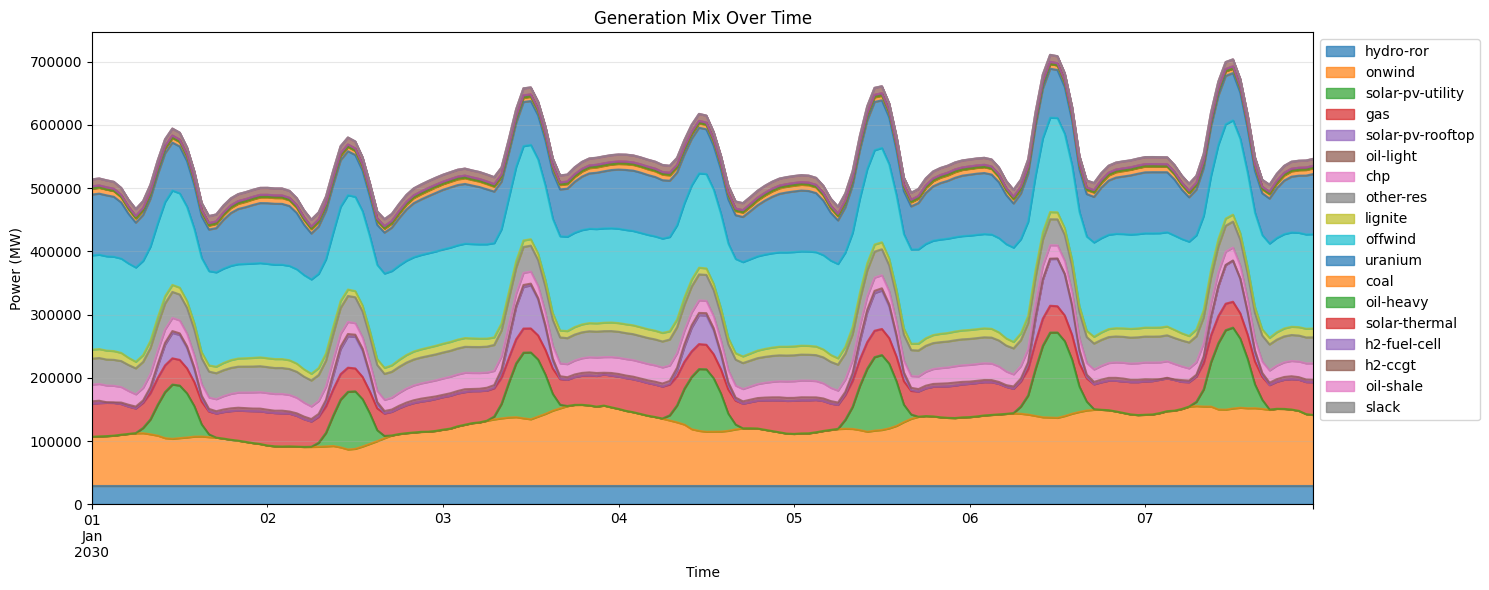

In [ ]:
# Create generation mix visualization
plot_generation_mix(network_test, save_path='generation_mix_1week.png')

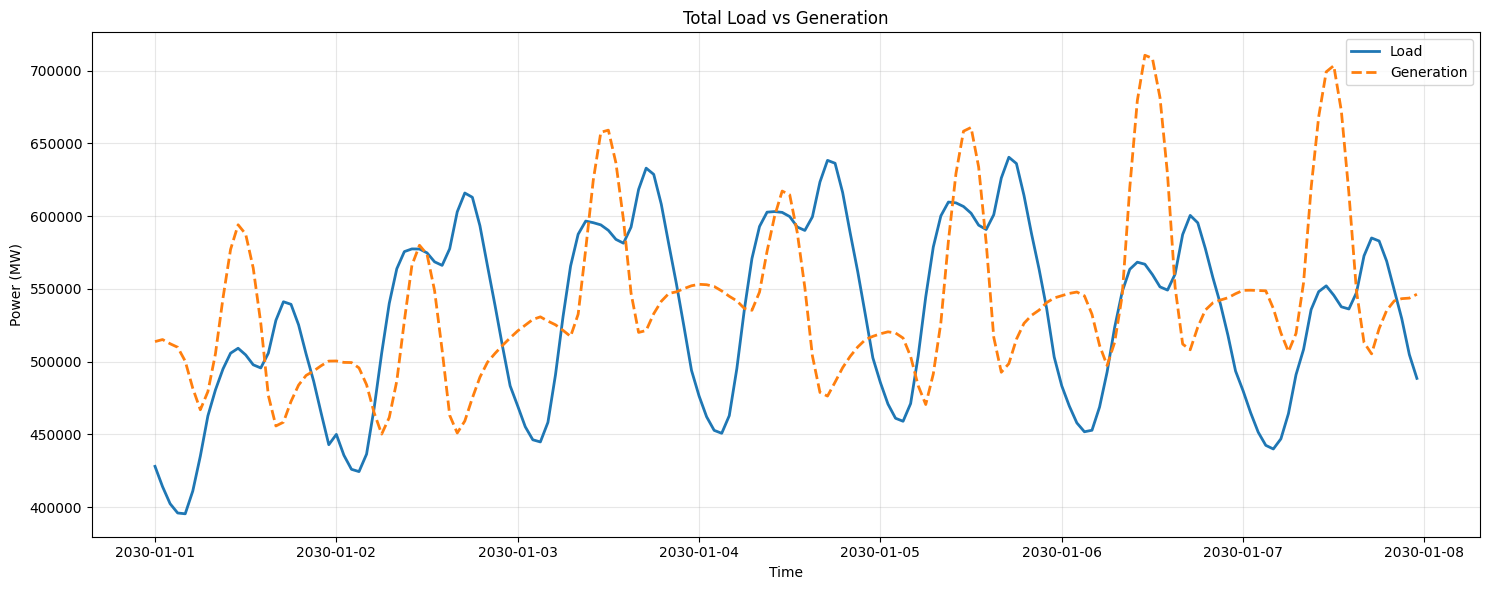

In [ ]:
# Plot load vs generation
plot_load_vs_generation(network_test, save_path='load_vs_generation_1week.png')

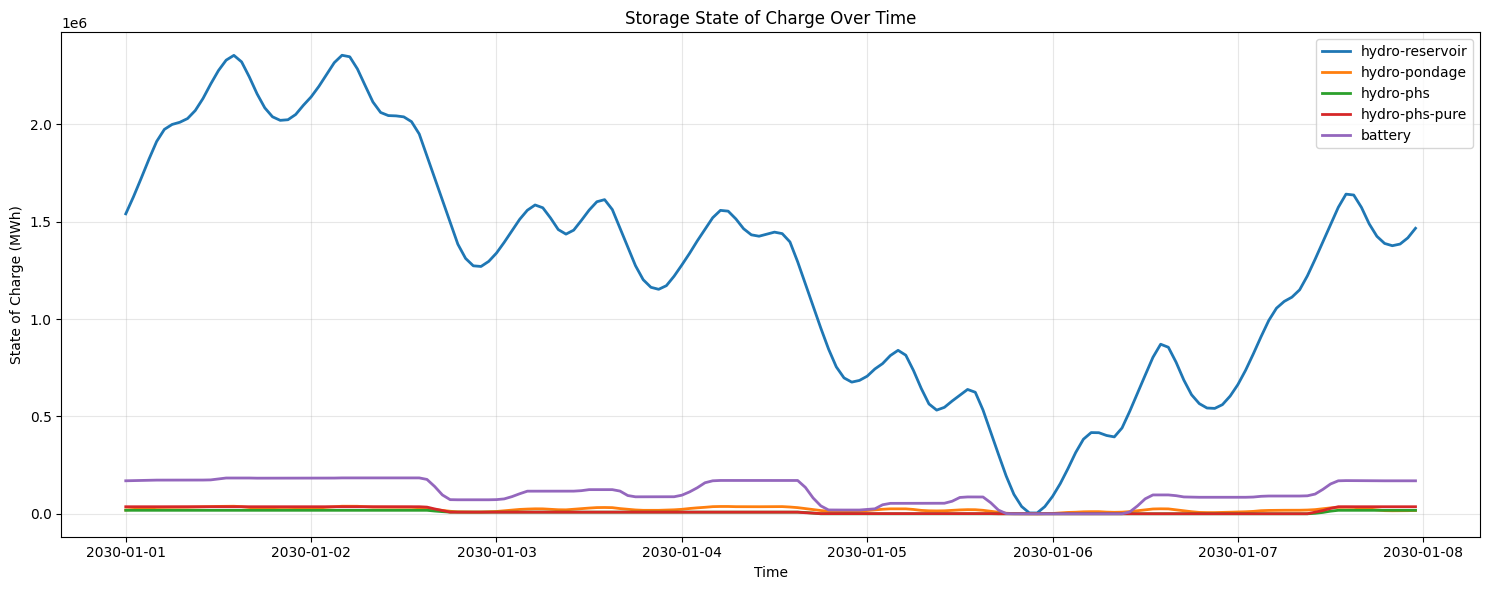

In [ ]:
# Plot storage state of charge
plot_storage_state(network_test, save_path='storage_state_1week.png')

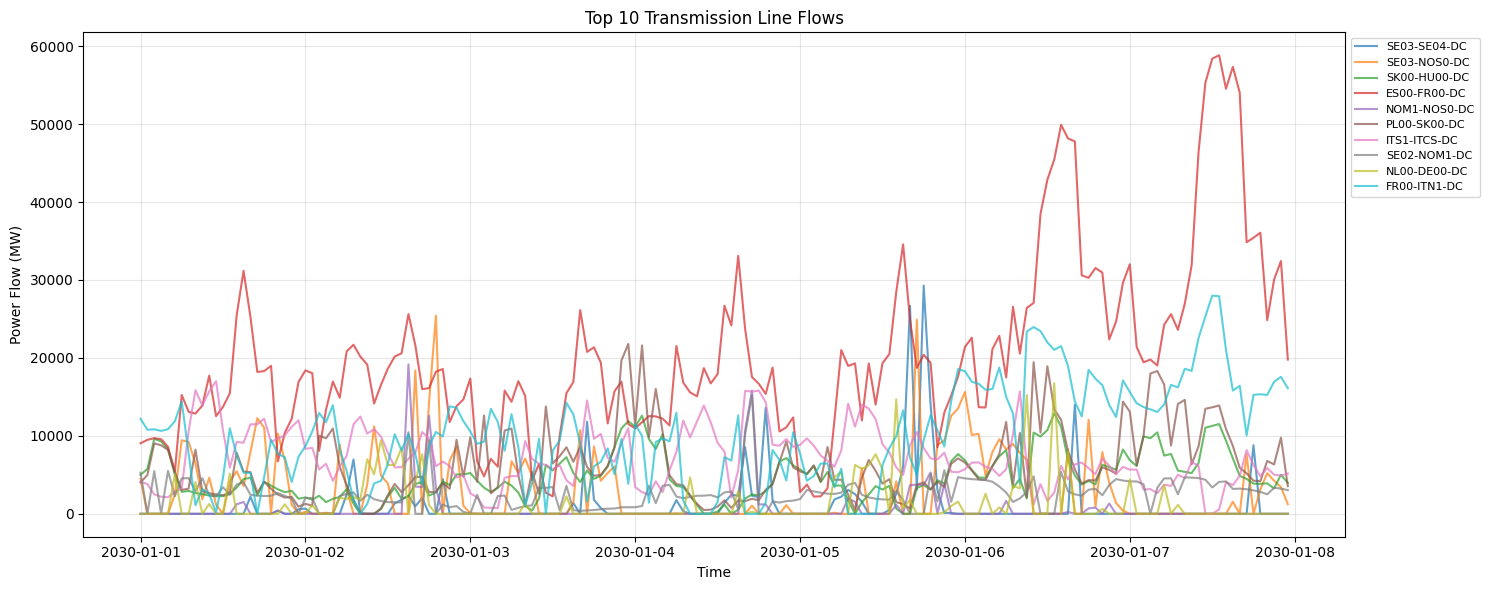

In [ ]:
# Plot transmission flows
plot_transmission_flows(network_test, save_path='transmission_flows_1week.png')

### Option 2: Full Year Optimization (8760 Hours)

Run optimization for the complete year 2030. **Warning: This will take several hours to days depending on hardware!**

In [ ]:
# Full year optimization setup
# ⚠️ DO NOT RUN THIS CELL UNLESS YOU HAVE SEVERAL HOURS/DAYS AVAILABLE! ⚠️

def run_full_year_optimization(network, solver_name='highs'):
    """
    Run full year optimization for the network.
    
    Parameters:
    -----------
    network : pypsa.Network
        The network to optimize
    solver_name : str
        Solver to use ('highs', 'gurobi', 'cplex', 'glpk')
    
    Returns:
    --------
    pypsa.Network
        Optimized network
    """
    import time
    
    print("🚀 Starting FULL YEAR optimization (8760 hours)...")
    print("=" * 60)
    print("⚠️  WARNING: This will take a LONG time!")
    print("   Expected time: 2-24 hours depending on hardware")
    print("   Recommended: Use Gurobi or CPLEX if available")
    print("   Current solver:", solver_name)
    print("=" * 60)
    
    start_time = time.time()
    
    try:
        # Run optimization
        network.optimize(
            solver_name=solver_name,
            solver_logfile='optimization_full_year.log',
            solver_options={
                'threads': 8,  # Use multiple CPU threads
                'Method': 2,   # Barrier method (faster for large problems)
                'Crossover': 0  # Disable crossover for faster solve
            } if solver_name == 'gurobi' else {}
        )
        
        elapsed_time = time.time() - start_time
        
        print(f"\n✅ FULL YEAR optimization completed!")
        print(f"   Time elapsed: {elapsed_time:.1f} seconds ({elapsed_time/3600:.2f} hours)")
        print(f"   Objective (total cost): €{network.objective:,.0f}")
        print(f"   Status: {network.status}")
        
        # Validation
        total_generation = network.generators_t.p.sum().sum()
        total_load = network.loads_t.p.sum().sum()
        
        print(f"\n📊 Validation:")
        print(f"   Total generation: {total_generation:,.0f} MWh")
        print(f"   Total load: {total_load:,.0f} MWh")
        print(f"   Balance error: {abs(total_generation - total_load):,.0f} MWh ({abs(total_generation - total_load)/total_load*100:.3f}%)")
        
        # Save results
        output_file = "tyndp2024_network_2030_optimized_full_year.nc"
        network.export_to_netcdf(output_file)
        print(f"\n💾 Results saved to: {output_file}")
        
        return network
        
    except Exception as e:
        elapsed_time = time.time() - start_time
        print(f"\n❌ Optimization failed after {elapsed_time:.1f} seconds")
        print(f"   Error: {str(e)}")
        print("   Check log file: optimization_full_year.log")
        raise

# Instructions for running
print("📝 To run full year optimization, execute:")
print("   optimized_network = run_full_year_optimization(network, solver_name='highs')")
print("\n💡 Tips for faster optimization:")
print("   1. Use commercial solver: solver_name='gurobi' (requires license)")
print("   2. Run on high-performance machine with many CPU cores")
print("   3. Consider time series aggregation to reduce snapshots")
print("   4. Run optimization overnight or over weekend")

📝 To run full year optimization, execute:
   optimized_network = run_full_year_optimization(network, solver_name='highs')

💡 Tips for faster optimization:
   1. Use commercial solver: solver_name='gurobi' (requires license)
   2. Run on high-performance machine with many CPU cores
   3. Consider time series aggregation to reduce snapshots
   4. Run optimization overnight or over weekend


### Summary: How to Run Optimizations

**Quick Test (1 Week - ~5-30 minutes):**
```python
# Already set up above - just run the cell with network_test.optimize()
```

**Full Year (8760 Hours - several hours to days):**
```python
# Run when ready (not now!):
optimized_network = run_full_year_optimization(network, solver_name='highs')
```

**Alternative: Optimize specific periods**
```python
# Example: Optimize just January 2030 (744 hours)
network_january = network.copy()
network_january.set_snapshots(pd.date_range('2030-01-01', periods=744, freq='h'))
# Copy time series for January...
network_january.optimize(solver_name='highs')
```

## Phase 8: Validation & Visualization

After optimization is complete, validate results and create visualizations.

In [ ]:
# Validation functions (run after optimization)
# These functions will work with either network_test or the full year optimized network

def validate_network_results(net):
    """
    Comprehensive validation of optimization results.
    
    Parameters:
    -----------
    net : pypsa.Network
        Optimized network to validate
    
    Returns:
    --------
    dict : Validation results
    """
    results = {}
    
    print("=" * 60)
    print("NETWORK VALIDATION REPORT")
    print("=" * 60)
    
    # 1. Energy Balance
    print("\n1️⃣  ENERGY BALANCE CHECK")
    total_gen = net.generators_t.p.sum().sum()
    total_storage_dispatch = net.storage_units_t.p.sum().sum()
    total_load = net.loads_t.p.sum().sum()
    total_transmission_loss = (net.links_t.p0.sum().sum() - net.links_t.p1.sum().sum()) if len(net.links) > 0 else 0
    
    balance_error = abs(total_gen + total_storage_dispatch - total_load)
    balance_error_pct = balance_error / total_load * 100
    
    print(f"   Generation: {total_gen:,.0f} MWh")
    print(f"   Storage dispatch: {total_storage_dispatch:,.0f} MWh")
    print(f"   Load: {total_load:,.0f} MWh")
    print(f"   Transmission losses: {total_transmission_loss:,.0f} MWh")
    print(f"   Balance error: {balance_error:,.0f} MWh ({balance_error_pct:.3f}%)")
    
    if balance_error_pct < 0.01:
        print("   ✅ Energy balance OK")
    else:
        print("   ⚠️  Energy balance has significant error")
    
    results['energy_balance'] = {
        'generation': total_gen,
        'load': total_load,
        'error_pct': balance_error_pct
    }
    
    # 2. Capacity Utilization
    print("\n2️⃣  CAPACITY UTILIZATION")
    for carrier in net.generators.carrier.unique():
        gens = net.generators[net.generators.carrier == carrier]
        total_capacity = gens.p_nom.sum()
        total_generation = net.generators_t.p[gens.index].sum().sum()
        max_possible = total_capacity * len(net.snapshots)
        utilization = total_generation / max_possible * 100 if max_possible > 0 else 0
        
        print(f"   {carrier:20s}: {utilization:6.2f}% ({total_generation:,.0f} MWh)")
    
    # 3. Renewable Curtailment
    print("\n3️⃣  RENEWABLE CURTAILMENT")
    renewable_carriers = ['onwind', 'offwind', 'solar-pv-utility', 'solar-pv-rooftop']
    total_curtailment = 0
    total_potential = 0
    
    for carrier in renewable_carriers:
        gens = net.generators[net.generators.carrier == carrier]
        if len(gens) > 0:
            for gen in gens.index:
                p_max_pu = net.generators_t.p_max_pu[gen]
                p_nom = net.generators.loc[gen, 'p_nom']
                potential = (p_max_pu * p_nom).sum()
                actual = net.generators_t.p[gen].sum()
                curtailment = potential - actual
                
                total_curtailment += curtailment
                total_potential += potential
    
    curtailment_pct = total_curtailment / total_potential * 100 if total_potential > 0 else 0
    print(f"   Total curtailment: {total_curtailment:,.0f} MWh ({curtailment_pct:.2f}%)")
    
    results['curtailment_pct'] = curtailment_pct
    
    # 4. Storage Cycling
    print("\n4️⃣  STORAGE CYCLING")
    for carrier in net.storage_units.carrier.unique():
        storage = net.storage_units[net.storage_units.carrier == carrier]
        if len(storage) > 0:
            total_charge = net.storage_units_t.p[storage.index][net.storage_units_t.p[storage.index] < 0].sum().sum()
            total_discharge = net.storage_units_t.p[storage.index][net.storage_units_t.p[storage.index] > 0].sum().sum()
            
            print(f"   {carrier:20s}: Charge={abs(total_charge):,.0f} MWh, Discharge={total_discharge:,.0f} MWh")
    
    # 5. Total System Cost
    print("\n5️⃣  SYSTEM COSTS")
    print(f"   Total objective: €{net.objective:,.0f}")
    print(f"   Average cost per MWh: €{net.objective/total_load:.2f}/MWh")
    
    results['total_cost'] = net.objective
    results['avg_cost_per_mwh'] = net.objective / total_load
    
    # 6. CO2 Emissions Estimate
    print("\n6️⃣  CO2 EMISSIONS ESTIMATE")
    # Simplified CO2 calculation (kg CO2/MWh)
    co2_factors = {
        'coal': 820,
        'lignite': 1000,
        'gas': 400,
        'oil-light': 650,
        'oil-heavy': 700,
        'uranium': 0,
        'onwind': 0,
        'offwind': 0,
        'solar-pv-utility': 0,
        'solar-pv-rooftop': 0,
        'hydro-ror': 0
    }
    
    total_co2 = 0
    for carrier, factor in co2_factors.items():
        gens = net.generators[net.generators.carrier == carrier]
        if len(gens) > 0:
            generation = net.generators_t.p[gens.index].sum().sum()
            co2 = generation * factor / 1000  # tonnes CO2
            total_co2 += co2
    
    co2_intensity = total_co2 / total_load * 1000 if total_load > 0 else 0
    print(f"   Total CO2: {total_co2:,.0f} tonnes")
    print(f"   CO2 intensity: {co2_intensity:.1f} kg CO2/MWh")
    
    results['co2_emissions'] = total_co2
    results['co2_intensity'] = co2_intensity
    
    print("\n" + "=" * 60)
    return results

print("✅ Validation functions defined")
print("\n📝 To validate results after optimization:")
print("   results = validate_network_results(network_test)  # for test")
print("   # or")
print("   results = validate_network_results(optimized_network)  # for full year")

✅ Validation functions defined

📝 To validate results after optimization:
   results = validate_network_results(network_test)  # for test
   # or
   results = validate_network_results(optimized_network)  # for full year


In [ ]:
# Visualization functions
import matplotlib.pyplot as plt

def plot_generation_mix(net, save_path=None):
    """Plot generation mix over time."""
    fig, ax = plt.subplots(figsize=(15, 6))
    
    # Aggregate generation by carrier
    gen_by_carrier = {}
    for carrier in net.generators.carrier.unique():
        gens = net.generators[net.generators.carrier == carrier]
        gen_by_carrier[carrier] = net.generators_t.p[gens.index].sum(axis=1)
    
    # Stack plot
    df_gen = pd.DataFrame(gen_by_carrier)
    df_gen.plot.area(ax=ax, alpha=0.7)
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Power (MW)')
    ax.set_title('Generation Mix Over Time')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
def plot_load_vs_generation(net, save_path=None):
    """Plot load vs total generation."""
    fig, ax = plt.subplots(figsize=(15, 6))
    
    total_load = net.loads_t.p.sum(axis=1)
    total_gen = net.generators_t.p.sum(axis=1)
    
    ax.plot(net.snapshots, total_load, label='Load', linewidth=2)
    ax.plot(net.snapshots, total_gen, label='Generation', linewidth=2, linestyle='--')
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Power (MW)')
    ax.set_title('Total Load vs Generation')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_storage_state(net, save_path=None):
    """Plot storage state of charge."""
    fig, ax = plt.subplots(figsize=(15, 6))
    
    for carrier in net.storage_units.carrier.unique():
        storage = net.storage_units[net.storage_units.carrier == carrier]
        if len(storage) > 0:
            total_soc = net.storage_units_t.state_of_charge[storage.index].sum(axis=1)
            ax.plot(net.snapshots, total_soc, label=carrier, linewidth=2)
    
    ax.set_xlabel('Time')
    ax.set_ylabel('State of Charge (MWh)')
    ax.set_title('Storage State of Charge Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_transmission_flows(net, save_path=None):
    """Plot key transmission line flows."""
    if len(net.links) == 0:
        print("No transmission links to plot")
        return
    
    fig, ax = plt.subplots(figsize=(15, 6))
    
    # Plot flows for top 10 most utilized links
    link_utilization = (net.links_t.p0.abs().max() / net.links.p_nom).sort_values(ascending=False)
    top_links = link_utilization.head(10).index
    
    for link in top_links:
        ax.plot(net.snapshots, net.links_t.p0[link], label=link, alpha=0.7)
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Power Flow (MW)')
    ax.set_title('Top 10 Transmission Line Flows')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

print("✅ Visualization functions defined")
print("\n📊 To create plots after optimization:")
print("   plot_generation_mix(network_test)")
print("   plot_load_vs_generation(network_test)")
print("   plot_storage_state(network_test)")
print("   plot_transmission_flows(network_test)")

✅ Visualization functions defined

📊 To create plots after optimization:
   plot_generation_mix(network_test)
   plot_load_vs_generation(network_test)
   plot_storage_state(network_test)
   plot_transmission_flows(network_test)


---

## 🎯 Complete Workflow Summary

### What We've Built:
1. ✅ **Network Model** for TYNDP 2030 with 55 buses, 219 HVDC links
2. ✅ **365 Generators** (1.6 TW capacity): wind, solar, hydro, nuclear, gas, coal
3. ✅ **120 Storage Units** (238 GW power, 194 TWh energy): batteries, PHS, reservoirs
4. ✅ **Time Series** for full year 2030 (8760 hours)
5. ✅ **Optimization Setup** for both test (1 week) and full year

### Next Steps:

#### Option A: Quick Test (Recommended First)
```python
# Run the 1-week test optimization cell above (should take 5-30 minutes)
# Then validate:
results = validate_network_results(network_test)
plot_generation_mix(network_test)
```

#### Option B: Full Year Optimization (When Ready)
```python
# WARNING: Takes several hours to days!
optimized_network = run_full_year_optimization(network, solver_name='highs')
results = validate_network_results(optimized_network)
```

#### Option C: Custom Period
```python
# Example: Just optimize January
network_jan = network.copy()
network_jan.set_snapshots(pd.date_range('2030-01-01', periods=744, freq='h'))
# ... copy time series for January ...
network_jan.optimize(solver_name='highs')
```

### Files Saved:
- `tyndp2024_network_2030_preoptimization.nc` (13.4 MB) - Ready for optimization
- `tyndp2024_network_2030_optimized_1week.nc` - After test run
- `tyndp2024_network_2030_optimized_full_year.nc` - After full year run

### Performance Tips:
- Use **Gurobi** if you have a license (10-100x faster than HiGHS)
- Run on machine with **16+ GB RAM** and **8+ CPU cores**
- Consider **time series aggregation** to reduce 8760 hours to fewer representative periods
- Monitor solver log files for progress

In [ ]:
# Verify AT00 generators - should include hydro-ror, solar, wind, etc.
at00_gens = network.generators[network.generators['bus'] == 'AT00']
print("AT00 Generators:")
print(at00_gens[['carrier', 'p_nom']].sort_values('carrier'))
print(f"\nTotal generators at AT00: {len(at00_gens)}")
print(f"Total capacity: {at00_gens['p_nom'].sum():.2f} MW")
print(f"\nCapacity by carrier:")
print(at00_gens.groupby('carrier')['p_nom'].sum().sort_values(ascending=False))

AT00 Generators:
                                carrier        p_nom
name                                                
AT00-chp                            chp   845.240000
AT00-electrolyser          electrolyser  1000.200000
AT00-gas                            gas  3373.290000
AT00-hydro-ror                hydro-ror  5228.625760
AT00-oil-light                oil-light   120.000000
AT00-onwind                      onwind  9000.001001
AT00-other-res                other-res   760.644555
AT00-solar-pv-rooftop  solar-pv-rooftop  6615.910333
AT00-solar-pv-utility  solar-pv-utility  5384.346667

Total generators at AT00: 9
Total capacity: 32328.26 MW

Capacity by carrier:
carrier
onwind              9000.001001
solar-pv-rooftop    6615.910333
solar-pv-utility    5384.346667
hydro-ror           5228.625760
gas                 3373.290000
electrolyser        1000.200000
chp                  845.240000
other-res            760.644555
oil-light            120.000000
Name: p_nom, dtype: float

In [ ]:
# Check the CSV to understand hydro structure
import pandas as pd

df = pd.read_csv('data/open-tyndp/pemmdb_capacities_2030_grouped.csv')

# Look at all AT00 hydro entries
at00_hydro = df[(df['bus'] == 'AT00') & (df['carrier'].str.contains('hydro', na=False))]

print("AT00 HYDRO entries in CSV:")
print("="*100)
print(at00_hydro[['index_carrier', 'carrier', 'p_nom', 'e_nom', 'unit', 'efficiency']].to_string())

print("\n\n🔍 Understanding the structure:")
print("- hydro-ror-turbine: RUN OF RIVER (generator)")
print("- hydro-pondage-turbine + hydro-pondage-reservoir: PONDAGE (storage with turbine)")
print("- hydro-reservoir-turbine + hydro-reservoir-reservoir: RESERVOIR (storage with turbine)")
print("- hydro-phs-turbine + hydro-phs-pump + hydro-phs-reservoir: PUMPED HYDRO STORAGE")
print("- hydro-phs-pure-turbine + hydro-phs-pure-pump + hydro-phs-pure-reservoir: PURE PHS")

print("\n\n💡 The negative values you see:")
print("  The PUMP rows have negative p_nom because they CONSUME power (not generate)")
print("  Example: hydro-phs-pump has negative capacity = pumping power")

AT00 HYDRO entries in CSV:
                 index_carrier          carrier       p_nom        e_nom unit  efficiency
662          hydro-ror-turbine        hydro-ror  5228.62576        0.000   MW         1.0
663    hydro-pondage-reservoir    hydro-pondage     0.00000     5332.957  MWh         1.0
664      hydro-pondage-turbine    hydro-pondage  1149.30700        0.000   MW         1.0
665  hydro-reservoir-reservoir  hydro-reservoir     0.00000   769036.568  MWh         1.0
666    hydro-reservoir-turbine  hydro-reservoir  2787.12900        0.000   MW         1.0
667        hydro-phs-reservoir        hydro-phs     0.00000  1746653.000  MWh         1.0
668          hydro-phs-turbine        hydro-phs  5607.50000        0.000   MW         1.0
669             hydro-phs-pump        hydro-phs -5532.92000        0.000   MW         1.0
670   hydro-phs-pure-reservoir   hydro-phs-pure     0.00000     3600.000  MWh         1.0
671     hydro-phs-pure-turbine   hydro-phs-pure   450.00000        0.000 

In [ ]:
# Verify AT00 against platform validation
print("AT00 CAPACITY VALIDATION vs PLATFORM")
print("="*80)

at00_gens = network.generators[network.generators['bus'] == 'AT00']
print("\n📊 AT00 Generators (as shown in plots):")
print(at00_gens[['carrier', 'p_nom']].sort_values('p_nom', ascending=False))

print("\n\n📋 Platform Validation Targets:")
print("  Wind (onwind):           9.0 GW")
print("  Solar (utility+rooftop): 12.0 GW")
print("  Other-res:               0.76 GW")
print("  Gas:                     3.0 GW")
print("  Hydro (excl. PHS):       9.0 GW")

print("\n\n✅ Current Network AT00:")
at00_summary = at00_gens.groupby('carrier')['p_nom'].sum() / 1000  # Convert to GW
print(f"  Wind (onwind):           {at00_summary.get('onwind', 0):.2f} GW")
solar_total = at00_summary.get('solar-pv-utility', 0) + at00_summary.get('solar-pv-rooftop', 0)
print(f"  Solar (utility+rooftop): {solar_total:.2f} GW")
print(f"  Other-res:               {at00_summary.get('other-res', 0):.2f} GW")
print(f"  Gas:                     {at00_summary.get('gas', 0):.2f} GW")
print(f"  Hydro (excl. PHS):       {at00_summary.get('hydro', 0):.2f} GW")

print("\n\n🔍 Match Analysis:")
print(f"  Wind:  {'✅' if abs(at00_summary.get('onwind', 0) - 9.0) < 0.1 else '❌'}")
print(f"  Solar: {'✅' if abs(solar_total - 12.0) < 0.1 else '❌'}")
print(f"  Other: {'✅' if abs(at00_summary.get('other-res', 0) - 0.76) < 0.1 else '❌'}")
print(f"  Gas:   {'✅' if abs(at00_summary.get('gas', 0) - 3.0) < 0.5 else '❌'}")
print(f"  Hydro: {'✅' if abs(at00_summary.get('hydro', 0) - 9.0) < 0.5 else '❌'}")

AT00 CAPACITY VALIDATION vs PLATFORM

📊 AT00 Generators (as shown in plots):
                                carrier        p_nom
name                                                
AT00-hydro                        hydro  9165.061760
AT00-onwind                      onwind  9000.001001
AT00-solar-pv-rooftop  solar-pv-rooftop  6615.910333
AT00-solar-pv-utility  solar-pv-utility  5384.346667
AT00-gas                            gas  3373.290000
AT00-electrolyser          electrolyser  1000.200000
AT00-chp                            chp   845.240000
AT00-other-res                other-res   760.644555
AT00-oil-light                oil-light   120.000000


📋 Platform Validation Targets:
  Wind (onwind):           9.0 GW
  Solar (utility+rooftop): 12.0 GW
  Other-res:               0.76 GW
  Gas:                     3.0 GW
  Hydro (excl. PHS):       9.0 GW


✅ Current Network AT00:
  Wind (onwind):           9.00 GW
  Solar (utility+rooftop): 12.00 GW
  Other-res:               0.76 GW
  G

In [ ]:
# Check which buses have no generators or storage
print("BUSES WITHOUT GENERATORS OR STORAGE")
print("="*80)

all_buses = set(network.buses.index)
buses_with_gen = set(network.generators['bus'].unique())
buses_with_storage = set(network.storage_units['bus'].unique())

buses_without_gen = all_buses - buses_with_gen
buses_without_storage = all_buses - buses_with_storage
buses_without_both = buses_without_gen & buses_without_storage

print(f"\n📊 Summary:")
print(f"  Total buses: {len(all_buses)}")
print(f"  Buses with generators: {len(buses_with_gen)}")
print(f"  Buses with storage: {len(buses_with_storage)}")

print(f"\n❌ Buses WITHOUT generators ({len(buses_without_gen)}):")
if buses_without_gen:
    print(f"  {sorted(buses_without_gen)}")
else:
    print("  None - all buses have generators ✅")

print(f"\n❌ Buses WITHOUT storage ({len(buses_without_storage)}):")
if buses_without_storage:
    print(f"  {sorted(buses_without_storage)}")
else:
    print("  None - all buses have storage ✅")

print(f"\n⚠️ Buses WITHOUT BOTH generators AND storage ({len(buses_without_both)}):")
if buses_without_both:
    print(f"  {sorted(buses_without_both)}")
    print(f"\n  These buses are pure transit nodes (transmission only)")
else:
    print("  None - all buses have at least generators or storage ✅")

BUSES WITHOUT GENERATORS OR STORAGE

📊 Summary:
  Total buses: 55
  Buses with generators: 50
  Buses with storage: 43

❌ Buses WITHOUT generators (5):
  ['ITCO', 'ITVI', 'LUB1', 'LUF1', 'LUV1']

❌ Buses WITHOUT storage (12):
  ['AL00', 'CY00', 'DKE1', 'EE00', 'FR15', 'ITCO', 'ITVI', 'LUB1', 'LUF1', 'ME00', 'MK00', 'MT00']

⚠️ Buses WITHOUT BOTH generators AND storage (4):
  ['ITCO', 'ITVI', 'LUB1', 'LUF1']

  These buses are pure transit nodes (transmission only)
